# Processing log files

This is for processing the data from the ``PackedRingBuffer``


In [1]:
# Helper methods and imports. Run this first and then any other cell will run
import numpy as np
import math
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import re
from datetime import datetime
import mpl_axes_aligner
#import importlib
from ReportingPlots import *  # or import Reporting.ReportingPlots as ReportingPlots

data_dir = Path("data") 

In [2]:
start_x = 188#48      # configurable first line
spacing = 180      # configurable gap between lines

rightThreadhold = 50
leftThreadhold = 40
frontThreadhold = 40


In [3]:
import importlib
import ReportingPlots  # or import Reporting.ReportingPlots as ReportingPlots
importlib.reload(ReportingPlots)

<module 'ReportingPlots' from '/home/paul/MicroMouseTools/Reporting/ReportingPlots.py'>

# Full plots

In [12]:

log_path = latest_dated_csv_path(data_dir)
df = pd.read_csv(log_path)
print(f"Loaded latest CSV: {log_path.name}")

Loaded latest CSV: 20260309_2.csv


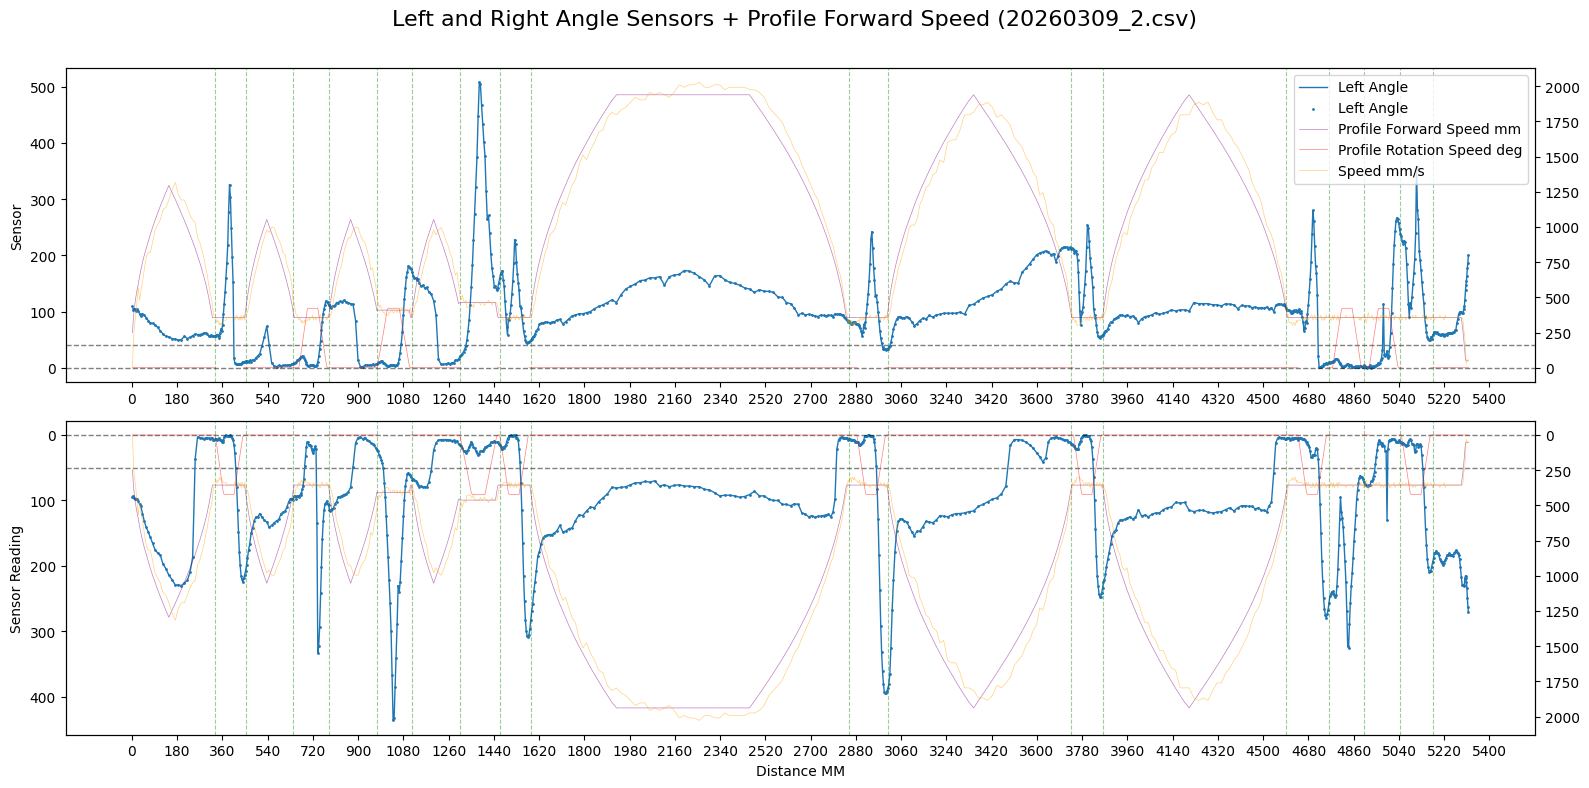

In [13]:


save_path = data_dir / "plots" / f"{log_path.stem}AngleSensorProfile_plot.png"

fig, _ = plot_sensor_vs_profile(
    df,
    left_threshold=leftThreadhold,
    right_threshold=rightThreadhold,
    title_label=log_path.name,
    tick_spacing_mm=180,
    save_path=save_path,
)

#display(fig)


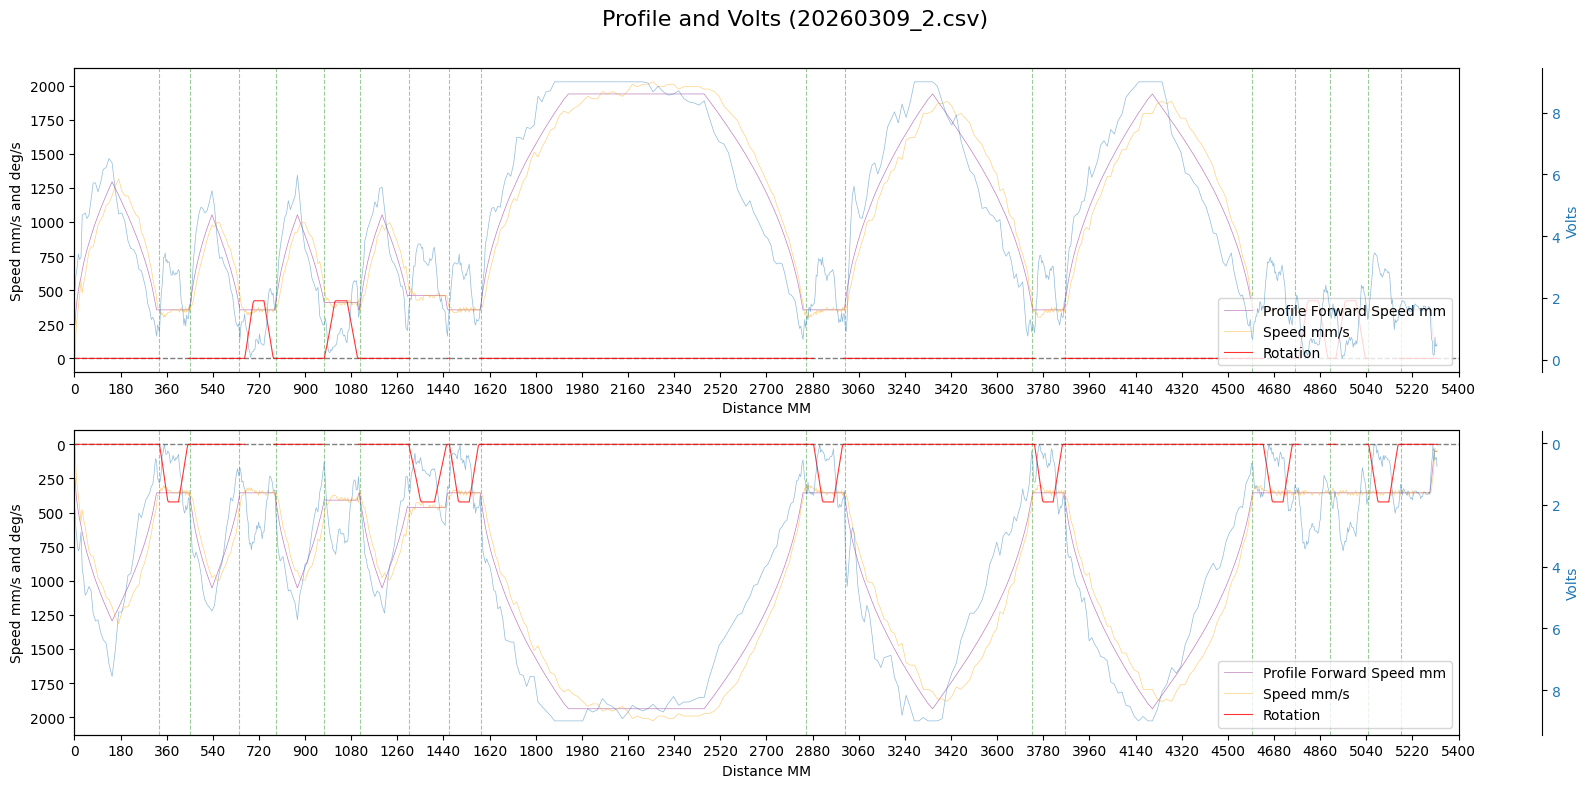

In [6]:

save_path = data_dir / "plots" / f"{log_path.stem}ProfileVolts_plot.png"

fig, _ = plot_profile_vs_volts(
    df,
    title_label=log_path.name,
    tick_spacing_mm=180,
    save_path=save_path,
)

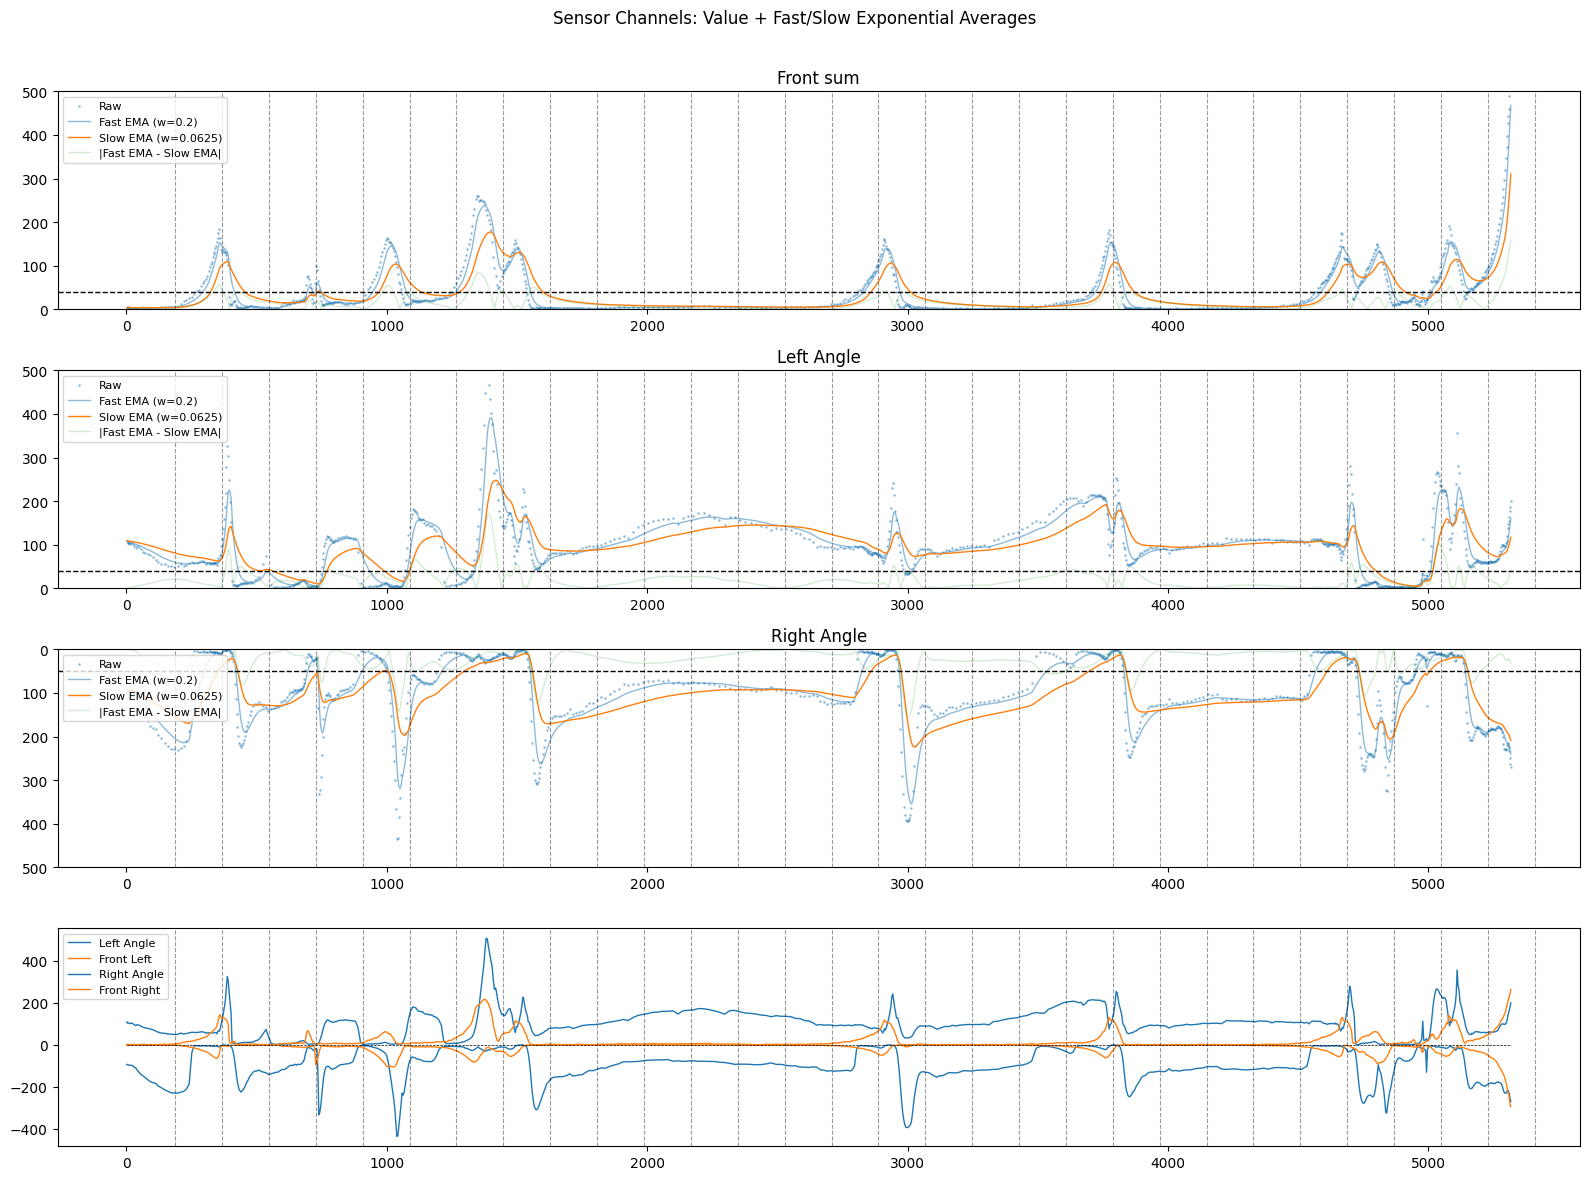

In [7]:
fig = plt.figure(figsize=(16, 12))

# choose an x max that covers your plotted data
x_max = df['Distance MM'].max()  # or df.index.max() if index is your x-axis

x_lines = np.arange(start_x, x_max + spacing, spacing)

plotLayout = (4, 1)

ax1 = plt.subplot2grid(plotLayout, (0, 0))
ax2 = plt.subplot2grid(plotLayout, (1, 0))
ax3 = plt.subplot2grid(plotLayout, (2, 0))
ax4 = plt.subplot2grid(plotLayout, (3, 0))

sensor_cols = [
    'Front sum',
    'Left Angle',
    'Right Angle',
]

w_fast = 0.2
w_slow = 0.0625

Xaxis = df['Distance MM']  # or df.index if index is your x-axis

for ax, col in zip((ax1, ax2, ax3), sensor_cols):
    fast_ema = df[col].ewm(alpha=w_fast, adjust=False).mean()
    slow_ema = df[col].ewm(alpha=w_slow, adjust=False).mean()
    ax.scatter(Xaxis, df[col], s=1, alpha=0.35, label='Raw')
    ax.plot(Xaxis, fast_ema, lw=1, label=f'Fast EMA (w={w_fast})', alpha=0.5)
    ax.plot(Xaxis, slow_ema, lw=1, label=f'Slow EMA (w={w_slow})')
    ax.plot(Xaxis, (fast_ema - slow_ema).abs(), lw=1, label='|Fast EMA - Slow EMA|', alpha=0.2)

    for x in x_lines:
        ax.axvline(x=x, color='black', linestyle='--', linewidth=0.8, alpha=0.4)

    
    ax.set_title(col)
    ax.set_ylim(top=500, bottom=0)
    ax.legend(loc='upper left', fontsize=8, frameon=True)

ax1.axhline(y=frontThreadhold, color='black', linestyle='--', linewidth=1)    
ax2.axhline(y=leftThreadhold, color='black', linestyle='--', linewidth=1)    
ax3.axhline(y=rightThreadhold, color='black', linestyle='--', linewidth=1)
ax3.invert_yaxis()  # Invert y-axis for Right Angle to match Left Angle orientation

ax4.plot(Xaxis, df['Left Angle'], label='Left Angle', lw=1, color='tab:blue')
ax4.plot(Xaxis, df['Front Left'], label='Front Left', lw=1, color='tab:orange')
ax4.plot(Xaxis, -df['Right Angle'], label='Right Angle', lw=1, color='tab:blue')
ax4.plot(Xaxis, -df['Front Right'], label='Front Right', lw=1, color='tab:orange')
ax4.plot(Xaxis, np.zeros(len(df)), color='k', lw=0.5, ls='--')
for x in x_lines:
        ax4.axvline(x=x, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
ax4.legend(loc='best', fontsize=8)

fig.suptitle('Sensor Channels: Value + Fast/Slow Exponential Averages')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()



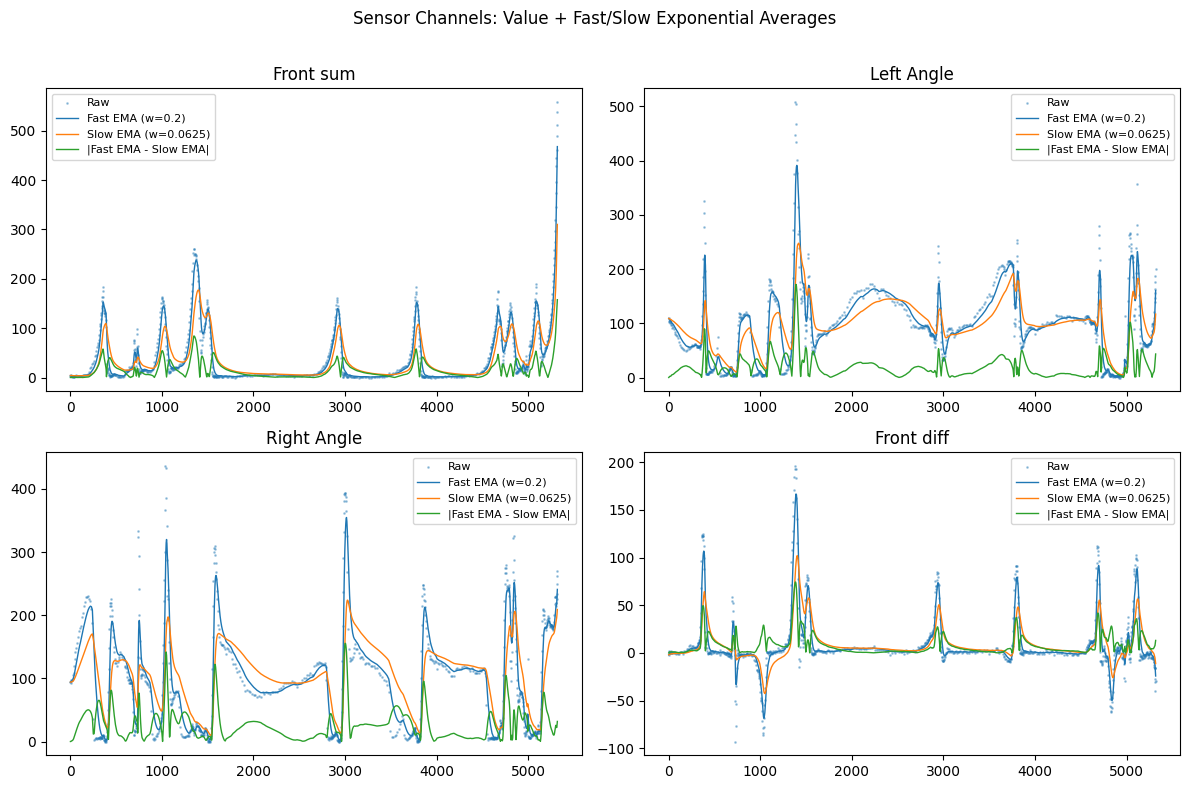

In [8]:

fig = plt.figure(figsize=(12, 8))

ax1 = plt.subplot2grid((2, 2), (0, 0))
ax2 = plt.subplot2grid((2, 2), (0, 1))
ax3 = plt.subplot2grid((2, 2), (1, 0))
ax4 = plt.subplot2grid((2, 2), (1, 1))

sensor_cols = [
    'Front sum',
    'Left Angle',
    'Right Angle',
    'Front diff',
]

w_fast = 0.2
w_slow = 0.0625

for ax, col in zip((ax1, ax2, ax3, ax4), sensor_cols):
    fast_ema = df[col].ewm(alpha=w_fast, adjust=False).mean()
    slow_ema = df[col].ewm(alpha=w_slow, adjust=False).mean()
    ax.scatter(df['Distance MM'], df[col], s=1, alpha=0.35, label='Raw')
    ax.plot(df['Distance MM'], fast_ema, lw=1, label=f'Fast EMA (w={w_fast})')
    ax.plot(df['Distance MM'], slow_ema, lw=1, label=f'Slow EMA (w={w_slow})')
    ax.plot(df['Distance MM'], (fast_ema - slow_ema).abs(), lw=1, label='|Fast EMA - Slow EMA|')
    ax.set_title(col)
    ax.legend(loc='best', fontsize=8)

fig.suptitle('Sensor Channels: Value + Fast/Slow Exponential Averages')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


# Create volts vs profile image for everything 

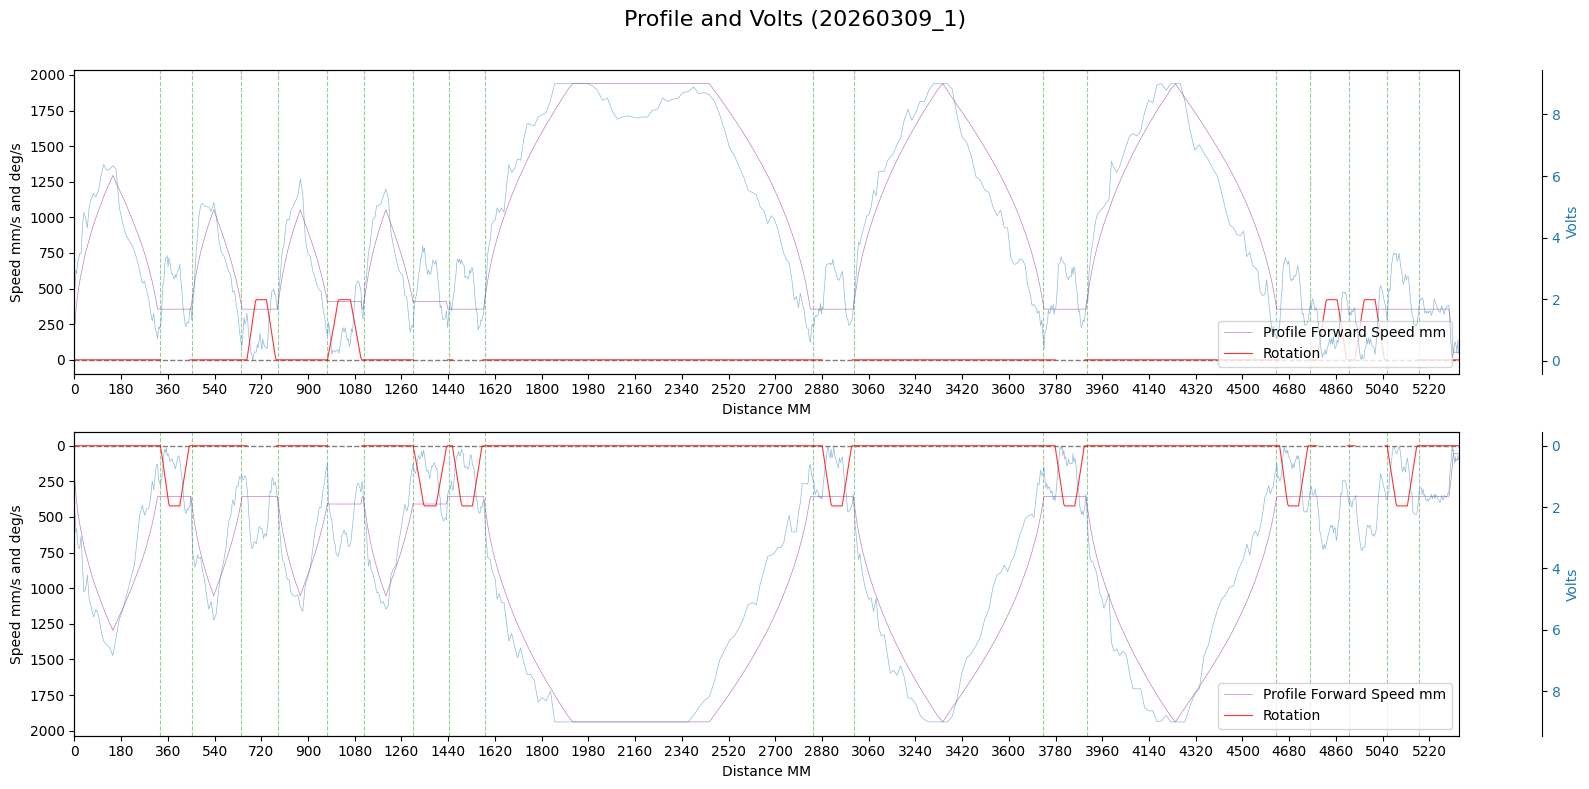

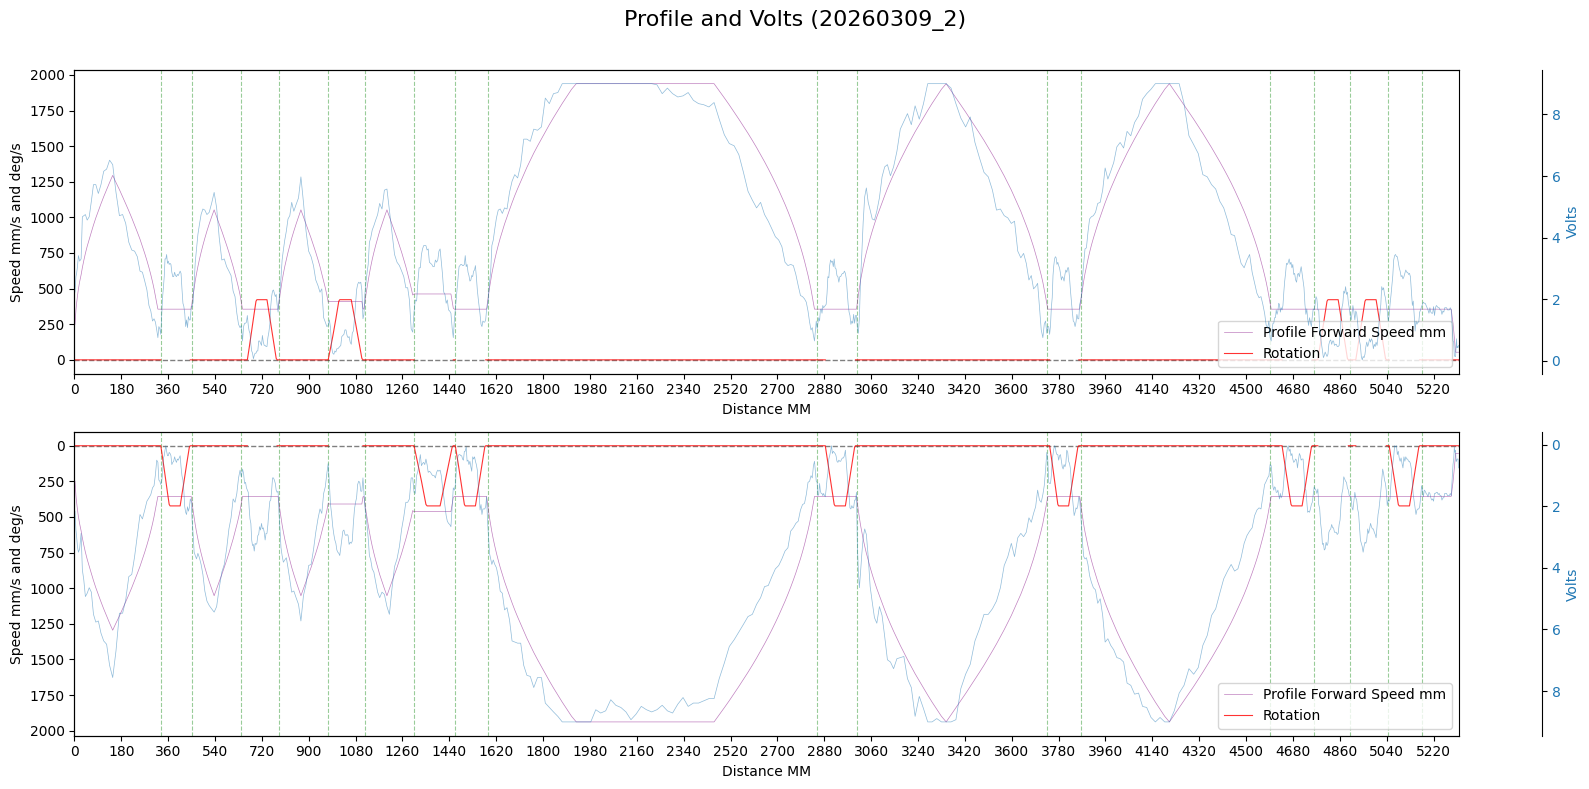

In [9]:

csv_files = sorted(data_dir.glob('*.csv'))

for log_path in csv_files:

    data_csv = Path(log_path)

    df = pd.read_csv(data_csv)

    # x-positions where maze location changes (row-to-row)
    change_x = df.loc[df['Maze Location'].ne(df['Maze Location'].shift()), 'Distance MM']
    #skip first row (it always counts as a "change" from NaN)
    change_x = change_x.iloc[1:]

    # setup plot layout
    fig = plt.figure(figsize=(16, 8))
    plotLayout = (2, 1)
    ax_left = plt.subplot2grid(plotLayout, (0, 0))
    ax_right = plt.subplot2grid(plotLayout, (1, 0))


    Xaxis = df['Distance MM']  # or df.index if index is your x-axis

    xLimitLow = 0
    xLimitHigh = Xaxis.max()  # or df.index.max() if index is your x-axis
    rot = df['Profile Rotation Speed deg']

    # Keep only left turns (positive)
    rot_left = rot.where(rot >= 0)              # negatives -> NaN (not drawn)

    # Keep only right turns (negative), then flip to positive magnitude
    rot_right = (-rot.where(rot <= 0)) 

    for ax in ((ax_left, ax_right)):

        ax.set_xlim(left=xLimitLow, right=xLimitHigh)
        ax.set_xticks(np.arange(xLimitLow, xLimitHigh + 1, 180))

        for x in change_x:
            ax.axvline(x=x, color='Green', linestyle='--', linewidth=0.8, alpha=0.4)
        ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
        # plot on new axis
        ax.plot(Xaxis, df['Profile Forward Speed mm'].abs(), color='purple', linewidth=0.5, label='Profile Forward Speed mm', alpha=0.5)


    ax_left.plot(Xaxis, rot_left, color='red', linewidth=0.8, alpha=0.8, label='Rotation')
    ax_right.plot(Xaxis, rot_right, color='red', linewidth=0.8, alpha=0.8, label='Rotation')

    ax_volts = ax_left.twinx()
    ax_volts.spines['right'].set_position(('outward', 60))  # shift 60 px
    ax_volts.plot(df['Distance MM'], df['LeftVolts'], color='tab:blue', linewidth=0.5, label='Left Volts', alpha=0.5)
    ax_volts.set_ylabel('Volts', color='tab:blue')
    ax_volts.tick_params(axis='y', labelcolor='tab:blue')

    ax_volts = ax_right.twinx()
    ax_volts.spines['right'].set_position(('outward', 60))  # shift 60 px
    ax_volts.plot(df['Distance MM'], df['RightVolts'], color='tab:blue', linewidth=0.5, label='Right Volts', alpha=0.5)
    ax_volts.set_ylabel('Volts', color='tab:blue')
    ax_volts.tick_params(axis='y', labelcolor='tab:blue')
    ax_volts.invert_yaxis()


    ax_left.legend(loc='lower right')
    ax_left.set_ylabel('Speed mm/s and deg/s')
    ax_left.set_xlabel('Distance MM')

    ax_right.invert_yaxis()
    ax_right.legend(loc='lower right')
    ax_right.set_ylabel('Speed mm/s and deg/s')
    ax_right.set_xlabel('Distance MM')

    fig.suptitle(f'Profile and Volts ({log_path.stem})', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    #plt.show()
    image_path = data_dir / Path("plots") / f"{log_path.stem}ProfileVolts_plot.png"
    fig.savefig(image_path, dpi=300, bbox_inches='tight')



# Telemtry Data Load


### Copy this into the below cell to speed up selecting what to paste

Once pasted execute all below cells to get the CSV created.

``` text
pasted_log = """
<PASTE THE FULL TXT LOG CONTENTS HERE>
"""
```

In [10]:
pasted_log = """
Start Buffer: size=811
FL, LA, RA, FR, dCount, mazeLoc, fwdSpeed, rotSpeed, lVolt, rVolt, cte, steerAdj, loopTick
Robot Data: [1, 109, 94, 3, 13, 0, 1400, 0, 62, 60, 0, 0, 7467]
Robot Data: [3, 103, 93, 2, 20, 0, 1960, 0, 76, 77, 0, 0, 7469]
Robot Data: [3, 104, 96, 1, 15, 0, 2240, 0, 79, 83, 0, 0, 7470]
Robot Data: [2, 104, 98, 2, 18, 0, 2520, 0, 85, 92, 0, 0, 7471]
Robot Data: [1, 101, 97, 1, 21, 0, 2800, 0, 95, 97, 0, 0, 7472]
Robot Data: [2, 104, 97, 1, 26, 0, 3080, 0, 90, 94, 0, 0, 7473]
Robot Data: [1, 101, 101, 1, 32, 0, 3360, 0, 92, 80, 0, 0, 7474]
Robot Data: [3, 96, 106, 1, 27, 0, 3640, 0, 130, 113, 0, 0, 7475]
Robot Data: [1, 92, 109, 1, 31, 0, 3920, 0, 131, 122, 0, 0, 7476]
Robot Data: [1, 96, 120, 1, 34, 0, 4200, 0, 132, 137, 0, 0, 7477]
Robot Data: [2, 94, 131, 1, 39, 0, 4480, 0, 127, 134, 0, 0, 7478]
Robot Data: [2, 89, 141, 2, 44, 0, 4760, 0, 130, 129, 0, 0, 7479]
Robot Data: [3, 84, 148, 2, 46, 0, 5040, 0, 144, 133, 0, 0, 7480]
Robot Data: [2, 80, 156, 2, 46, 0, 5320, 0, 159, 153, 0, 0, 7481]
Robot Data: [1, 79, 165, 2, 50, 0, 5600, 0, 159, 160, 0, 0, 7482]
Robot Data: [2, 76, 175, 2, 55, 0, 5880, 0, 151, 159, 0, 0, 7483]
Robot Data: [1, 72, 180, 2, 57, 0, 6160, 0, 159, 170, 0, 0, 7484]
Robot Data: [1, 66, 183, 2, 59, 0, 6440, 0, 171, 177, 0, 0, 7485]
Robot Data: [2, 60, 197, 1, 63, 0, 6720, 0, 173, 180, 0, 0, 7486]
Robot Data: [3, 56, 204, 2, 64, 0, 7000, 0, 181, 199, 148, 4, 7487]
Robot Data: [3, 55, 214, 2, 67, 0, 7280, 0, 177, 210, 159, 4, 7488]
Robot Data: [2, 52, 221, 3, 71, 0, 7000, 0, 152, 186, 169, 5, 7489]
Robot Data: [4, 51, 229, 2, 74, 0, 6720, 0, 131, 152, 178, 5, 7490]
Robot Data: [4, 49, 229, 2, 69, 0, 6440, 0, 132, 152, 180, 5, 7491]
Robot Data: [6, 50, 230, 2, 67, 0, 6160, 0, 124, 140, 180, 5, 7492]
Robot Data: [8, 56, 226, 4, 67, 0, 5880, 0, 107, 119, 170, 5, 7493]
Robot Data: [13, 52, 222, 6, 64, 0, 5600, 0, 100, 117, 170, 5, 7494]
Robot Data: [15, 54, 210, 7, 61, 0, 5320, 0, 99, 101, 156, 4, 7495]
Robot Data: [16, 57, 187, 11, 59, 0, 5040, 0, 94, 82, 130, 3, 7496]
Robot Data: [18, 60, 36, 11, 58, 0, 4760, 0, 81, 63, 80, 2, 7497]
Robot Data: [19, 59, 3, 15, 52, 0, 4480, 0, 80, 67, 82, 2, 7498]
Robot Data: [25, 59, 4, 18, 50, 0, 4200, 0, 72, 59, -1, -1, 7499]
Robot Data: [25, 60, 5, 20, 47, 0, 3920, 0, 64, 51, -1, -1, 7500]
Robot Data: [30, 62, 6, 24, 44, 0, 3640, 0, 50, 48, -1, -1, 7501]
Robot Data: [33, 62, 4, 28, 40, 0, 3360, 0, 45, 45, -1, -1, 7502]
Robot Data: [35, 60, 5, 30, 37, 0, 3080, 0, 36, 39, -1, -1, 7503]
Robot Data: [38, 56, 5, 32, 33, 0, 2800, 0, 38, 37, -1, -1, 7504]
Robot Data: [42, 57, 6, 35, 30, 0, 2520, 0, 35, 27, -1, -1, 7505]
Robot Data: [48, 58, 5, 39, 28, 0, 2240, 0, 28, 14, -1, -1, 7506]
Robot Data: [53, 56, 4, 43, 25, 0, 2000, 0, 21, 16, -1, -1, 7507]
Robot Data: [57, 57, 7, 47, 21, 0, 2000, 0, 31, 32, -1, -1, 7508]
Robot Data: [60, 57, 7, 49, 21, 0, 2000, 0, 29, 33, -1, -1, 7509]
Robot Data: [65, 56, 6, 54, 21, 2, 2000, 0, 24, 36, 0, 0, 7510]
Robot Data: [70, 57, 6, 56, 19, 2, 2000, -303, 42, 33, 0, 0, 7511]
Robot Data: [72, 59, 7, 59, 18, 2, 2000, -606, 57, 27, 0, 0, 7512]
Robot Data: [77, 59, 6, 63, 19, 2, 2000, -909, 66, 12, 0, 0, 7513]
Robot Data: [81, 57, 5, 64, 18, 2, 2000, -1212, 76, 10, 0, 0, 7514]
Robot Data: [91, 53, 6, 64, 17, 2, 2000, -1515, 92, 5, 0, 0, 7515]
Robot Data: [103, 62, 8, 61, 18, 2, 2000, -1818, 92, 1, 0, 0, 7516]
Robot Data: [122, 69, 8, 54, 17, 2, 2000, -2121, 96, 6, 0, 0, 7517]
Robot Data: [140, 65, 10, 44, 18, 2, 2000, -2424, 88, 10, 0, 0, 7518]
Robot Data: [143, 76, 11, 21, 18, 2, 2000, -2727, 90, 10, 0, 0, 7519]
Robot Data: [130, 96, 8, 6, 19, 2, 2000, -3030, 87, 7, 0, 0, 7520]
Robot Data: [127, 114, 3, 4, 19, 2, 2000, -3108, 88, 8, 0, 0, 7521]
Robot Data: [130, 135, 2, 5, 19, 2, 2000, -3108, 87, 10, 0, 0, 7522]
Robot Data: [127, 159, 0, 4, 19, 2, 2000, -3108, 80, 18, 0, 0, 7523]
Robot Data: [127, 186, 1, 4, 20, 2, 2000, -3108, 76, 16, 0, 0, 7524]
Robot Data: [123, 218, 2, 5, 20, 2, 2000, -3108, 76, 15, 0, 0, 7525]
Robot Data: [118, 278, 1, 6, 20, 2, 2000, -3108, 80, 11, 0, 0, 7526]
Robot Data: [108, 326, 2, 8, 20, 2, 2000, -3108, 77, 14, 0, 0, 7527]
Robot Data: [95, 303, 0, 7, 20, 2, 2000, -3108, 76, 16, 0, 0, 7528]
Robot Data: [25, 249, 2, 3, 20, 2, 2000, -3108, 78, 13, 0, 0, 7529]
Robot Data: [8, 197, 5, 3, 20, 2, 2000, -3108, 77, 14, 0, 0, 7530]
Robot Data: [8, 152, 8, 2, 20, 2, 2000, -3108, 79, 12, 0, 0, 7531]
Robot Data: [11, 17, 15, 2, 20, 2, 2000, -3108, 81, 10, 0, 0, 7532]
Robot Data: [14, 8, 27, 2, 19, 2, 2000, -2805, 79, 20, 0, 0, 7533]
Robot Data: [17, 7, 50, 2, 20, 2, 2000, -2502, 65, 28, 0, 0, 7534]
Robot Data: [16, 7, 79, 2, 21, 2, 2000, -2199, 52, 32, 0, 0, 7535]
Robot Data: [7, 6, 114, 2, 20, 2, 2000, -1896, 49, 42, 0, 0, 7536]
Robot Data: [4, 6, 148, 2, 19, 2, 2000, -1593, 43, 56, 0, 0, 7537]
Robot Data: [3, 7, 178, 3, 20, 2, 2000, -1290, 31, 61, 0, 0, 7538]
Robot Data: [1, 7, 199, 2, 19, 2, 2000, -987, 37, 63, 0, 0, 7539]
Robot Data: [1, 7, 215, 1, 21, 2, 2000, -684, 30, 56, 0, 0, 7540]
Robot Data: [3, 9, 220, 3, 19, 2, 2000, -381, 40, 60, 0, 0, 7541]
Robot Data: [2, 11, 225, 2, 20, 2, 2000, -78, 37, 57, 0, 0, 7542]
Robot Data: [2, 10, 219, 2, 21, 2, 2000, 0, 37, 49, 0, 0, 7543]
Robot Data: [2, 11, 214, 2, 19, 2, 2000, 0, 49, 51, 0, 0, 7544]
Robot Data: [3, 12, 208, 1, 20, 18, 2280, 0, 49, 68, 216, 7, 7545]
Robot Data: [3, 11, 199, 2, 22, 18, 2560, 0, 53, 81, 198, 5, 7546]
Robot Data: [2, 12, 188, 3, 22, 18, 2840, 0, 70, 97, 176, 5, 7547]
Robot Data: [3, 11, 176, 3, 24, 18, 3120, 0, 89, 100, 152, 4, 7548]
Robot Data: [4, 13, 166, 2, 27, 18, 3400, 0, 101, 103, 132, 3, 7549]
Robot Data: [5, 11, 150, 3, 30, 18, 3680, 0, 114, 98, 100, 2, 7550]
Robot Data: [5, 14, 142, 3, 33, 18, 3960, 0, 123, 102, 84, 2, 7551]
Robot Data: [3, 13, 131, 3, 36, 18, 4240, 0, 132, 108, 62, 1, 7552]
Robot Data: [3, 18, 125, 2, 39, 18, 4520, 0, 137, 117, 50, 1, 7553]
Robot Data: [3, 21, 125, 2, 42, 18, 4800, 0, 136, 132, 50, 1, 7554]
Robot Data: [3, 25, 120, 1, 45, 18, 5080, 0, 132, 141, 40, 1, 7555]
Robot Data: [1, 39, 126, 1, 49, 18, 5360, 0, 134, 145, 52, 1, 7556]
Robot Data: [1, 55, 130, 1, 52, 18, 5640, 0, 142, 148, 75, 2, 7557]
Robot Data: [2, 74, 133, 1, 55, 18, 5920, 0, 152, 151, 59, 1, 7558]
Robot Data: [1, 40, 141, 1, 54, 18, 5640, 0, 138, 146, 82, 2, 7559]
Robot Data: [0, 8, 138, 2, 56, 18, 5360, 0, 111, 129, 76, 2, 7560]
Robot Data: [3, 3, 134, 0, 56, 18, 5080, 0, 91, 115, 68, 2, 7561]
Robot Data: [1, 2, 131, 1, 53, 18, 4800, 0, 92, 108, 62, 1, 7562]
Robot Data: [2, 4, 129, 1, 51, 18, 4520, 0, 85, 94, 58, 1, 7563]
Robot Data: [4, 3, 120, 3, 49, 18, 4240, 0, 81, 76, 40, 1, 7564]
Robot Data: [7, 4, 118, 7, 46, 18, 3960, 0, 77, 66, 36, 1, 7565]
Robot Data: [7, 4, 116, 7, 45, 18, 3680, 0, 63, 49, 32, 0, 7566]
Robot Data: [6, 4, 110, 7, 41, 18, 3400, 0, 58, 52, 20, 0, 7567]
Robot Data: [7, 5, 102, 8, 39, 18, 3120, 0, 43, 44, 4, 0, 7568]
Robot Data: [6, 4, 98, 7, 37, 18, 2840, 0, 33, 30, -4, -1, 7569]
Robot Data: [7, 7, 97, 9, 33, 18, 2560, 0, 30, 23, -6, -1, 7570]
Robot Data: [11, 6, 99, 10, 27, 34, 2280, 0, 32, 29, 0, 0, 7571]
Robot Data: [6, 8, 93, 9, 26, 34, 2000, 0, 18, 22, 0, 0, 7572]
Robot Data: [8, 9, 93, 9, 23, 34, 2000, 0, 31, 26, 0, 0, 7573]
Robot Data: [9, 10, 97, 9, 21, 34, 2000, 0, 34, 35, 0, 0, 7574]
Robot Data: [7, 13, 93, 10, 21, 34, 2000, 0, 34, 34, 0, 0, 7575]
Robot Data: [10, 13, 93, 10, 20, 34, 2000, 0, 35, 39, 0, 0, 7576]
Robot Data: [7, 15, 94, 10, 19, 34, 2000, 0, 41, 41, 0, 0, 7577]
Robot Data: [10, 17, 92, 11, 20, 34, 2000, 303, 32, 43, 0, 0, 7578]
Robot Data: [9, 19, 92, 11, 19, 34, 2000, 606, 27, 57, 0, 0, 7579]
Robot Data: [8, 19, 88, 12, 18, 34, 2000, 909, 25, 67, 0, 0, 7580]
Robot Data: [10, 20, 83, 13, 19, 34, 2000, 1212, 15, 71, 0, 0, 7581]
Robot Data: [7, 20, 78, 12, 18, 34, 2000, 1515, 9, 86, 0, 0, 7582]
Robot Data: [10, 18, 67, 13, 18, 34, 2000, 1818, 7, 91, 0, 0, 7583]
Robot Data: [16, 14, 47, 13, 19, 34, 2000, 2121, 2, 90, 0, 0, 7584]
Robot Data: [44, 11, 32, 11, 18, 34, 2000, 2424, 5, 96, 0, 0, 7585]
Robot Data: [64, 7, 18, 10, 19, 34, 2000, 2727, 7, 89, 0, 0, 7586]
Robot Data: [68, 4, 11, 9, 19, 34, 2000, 3030, 7, 90, 0, 0, 7587]
Robot Data: [61, 3, 11, 9, 19, 34, 2000, 3108, 9, 89, 0, 0, 7588]
Robot Data: [51, 3, 16, 7, 20, 34, 2000, 3108, 9, 82, 0, 0, 7589]
Robot Data: [41, 4, 15, 8, 19, 34, 2000, 3108, 18, 81, 0, 0, 7590]
Robot Data: [29, 4, 17, 6, 20, 34, 2000, 3108, 18, 74, 0, 0, 7591]
Robot Data: [18, 5, 22, 5, 20, 34, 2000, 3108, 16, 77, 0, 0, 7592]
Robot Data: [10, 5, 27, 5, 21, 34, 2000, 3108, 14, 71, 0, 0, 7593]
Robot Data: [7, 4, 25, 9, 19, 34, 2000, 3108, 23, 76, 0, 0, 7594]
Robot Data: [5, 3, 22, 56, 20, 34, 2000, 3108, 17, 75, 0, 0, 7595]
Robot Data: [3, 3, 17, 96, 20, 34, 2000, 3108, 14, 79, 0, 0, 7596]
Robot Data: [6, 3, 21, 83, 19, 34, 2000, 3108, 14, 86, 0, 0, 7597]
Robot Data: [5, 5, 134, 59, 20, 34, 2000, 3108, 13, 80, 0, 0, 7598]
Robot Data: [5, 11, 333, 40, 20, 34, 2000, 3108, 13, 80, 0, 0, 7599]
Robot Data: [7, 20, 323, 23, 20, 34, 2000, 2805, 21, 72, 0, 0, 7600]
Robot Data: [8, 33, 293, 10, 21, 34, 2000, 2502, 26, 60, 0, 0, 7601]
Robot Data: [8, 48, 242, 5, 21, 34, 2000, 2199, 33, 51, 0, 0, 7602]
Robot Data: [5, 67, 201, 5, 19, 34, 2000, 1896, 49, 50, 0, 0, 7603]
Robot Data: [5, 82, 159, 5, 19, 34, 2000, 1593, 58, 42, 0, 0, 7604]
Robot Data: [3, 96, 132, 6, 20, 34, 2000, 1290, 63, 30, 0, 0, 7605]
Robot Data: [5, 105, 115, 7, 20, 34, 2000, 987, 64, 30, 0, 0, 7606]
Robot Data: [6, 112, 105, 8, 20, 34, 2000, 684, 61, 32, 0, 0, 7607]
Robot Data: [6, 119, 104, 7, 20, 34, 2000, 381, 58, 35, 0, 0, 7608]
Robot Data: [6, 117, 101, 8, 19, 34, 2000, 78, 60, 41, 0, 0, 7609]
Robot Data: [6, 117, 105, 8, 20, 34, 2000, 0, 51, 43, 0, 0, 7610]
Robot Data: [6, 111, 107, 8, 21, 34, 2000, 0, 44, 42, 0, 0, 7611]
Robot Data: [7, 112, 114, 8, 20, 35, 2280, 0, 54, 62, 2, 0, 7612]
Robot Data: [6, 108, 116, 8, 21, 35, 2560, 0, 65, 76, 8, 0, 7613]
Robot Data: [7, 107, 115, 8, 22, 35, 2840, 0, 75, 93, 8, 0, 7614]
Robot Data: [7, 109, 113, 9, 24, 35, 3120, 0, 91, 100, 4, 0, 7615]
Robot Data: [7, 110, 111, 9, 27, 35, 3400, 0, 100, 106, 1, 0, 7616]
Robot Data: [8, 111, 105, 9, 30, 35, 3680, 0, 109, 104, -6, -1, 7617]
Robot Data: [6, 116, 102, 10, 34, 35, 3960, 0, 117, 102, -14, -1, 7618]
Robot Data: [7, 116, 95, 9, 36, 35, 4240, 0, 128, 111, -21, -1, 7619]
Robot Data: [7, 118, 94, 8, 39, 35, 4520, 0, 131, 122, -24, -1, 7620]
Robot Data: [5, 117, 93, 8, 41, 35, 4800, 0, 143, 133, -24, -1, 7621]
Robot Data: [5, 120, 91, 6, 46, 35, 5080, 0, 135, 132, -29, -1, 7622]
Robot Data: [6, 117, 90, 6, 49, 35, 5360, 0, 141, 138, -27, -1, 7623]
Robot Data: [7, 116, 87, 7, 52, 35, 5640, 0, 147, 144, -29, -1, 7624]
Robot Data: [5, 114, 80, 7, 52, 35, 5920, 0, 166, 159, -34, -2, 7625]
Robot Data: [6, 113, 49, 8, 55, 35, 5640, 0, 143, 136, -26, -1, 7626]
Robot Data: [8, 84, 12, 8, 56, 35, 5360, 0, 117, 126, 32, 1, 7627]
Robot Data: [8, 13, 4, 10, 56, 35, 5080, 0, 99, 109, 0, -1, 7628]
Robot Data: [10, 2, 3, 13, 53, 35, 4800, 0, 94, 108, 0, 0, 7629]
Robot Data: [15, 2, 6, 17, 51, 35, 4520, 0, 86, 95, 0, 0, 7630]
Robot Data: [22, 4, 4, 24, 50, 35, 4240, 0, 73, 79, 0, 0, 7631]
Robot Data: [22, 5, 8, 29, 47, 35, 3960, 0, 68, 67, 0, 0, 7632]
Robot Data: [27, 4, 9, 35, 44, 35, 3680, 0, 62, 58, 0, 0, 7633]
Robot Data: [31, 5, 12, 39, 39, 35, 3400, 0, 65, 62, 0, 0, 7634]
Robot Data: [33, 6, 14, 46, 40, 35, 3120, 0, 39, 44, 0, 0, 7635]
Robot Data: [34, 5, 16, 52, 36, 35, 2840, 0, 35, 38, 0, 0, 7636]
Robot Data: [40, 6, 20, 58, 33, 35, 2560, 0, 31, 26, 0, 0, 7637]
Robot Data: [45, 7, 23, 64, 29, 36, 2280, 0, 32, 17, 0, 0, 7638]
Robot Data: [51, 8, 25, 71, 26, 36, 2300, 303, 37, 35, 0, 0, 7639]
Robot Data: [55, 10, 30, 77, 24, 36, 2300, 606, 30, 54, 0, 0, 7640]
Robot Data: [58, 10, 33, 82, 25, 36, 2300, 909, 12, 63, 0, 0, 7641]
Robot Data: [62, 12, 38, 88, 24, 36, 2300, 1212, 7, 74, 0, 0, 7642]
Robot Data: [63, 12, 43, 96, 23, 36, 2300, 1515, 6, 81, 0, 0, 7643]
Robot Data: [61, 9, 51, 102, 22, 36, 2300, 1818, 9, 86, 0, 0, 7644]
Robot Data: [56, 8, 74, 105, 22, 36, 2300, 2121, 8, 89, 0, 0, 7645]
Robot Data: [52, 6, 94, 103, 21, 36, 2300, 2424, 11, 95, 0, 0, 7646]
Robot Data: [54, 5, 124, 101, 21, 36, 2300, 2727, 11, 97, 0, 0, 7647]
Robot Data: [49, 3, 153, 102, 21, 36, 2300, 3030, 12, 98, 0, 0, 7648]
Robot Data: [43, 3, 187, 104, 21, 36, 2300, 3108, 13, 100, 0, 0, 7649]
Robot Data: [35, 3, 222, 106, 22, 36, 2300, 3108, 14, 93, 0, 0, 7650]
Robot Data: [27, 4, 256, 106, 22, 36, 2300, 3108, 22, 86, 0, 0, 7651]
Robot Data: [19, 5, 300, 103, 23, 36, 2300, 3108, 23, 78, 0, 0, 7652]
Robot Data: [11, 5, 366, 97, 23, 36, 2300, 3108, 24, 77, 0, 0, 7653]
Robot Data: [9, 5, 436, 87, 22, 36, 2300, 3108, 28, 81, 0, 0, 7654]
Robot Data: [7, 4, 433, 75, 22, 36, 2300, 3108, 28, 82, 0, 0, 7655]
Robot Data: [4, 3, 385, 59, 23, 36, 2300, 3108, 23, 81, 0, 0, 7656]
Robot Data: [4, 4, 341, 53, 23, 36, 2300, 3108, 21, 82, 0, 0, 7657]
Robot Data: [5, 4, 288, 42, 22, 36, 2300, 3108, 22, 90, 0, 0, 7658]
Robot Data: [5, 8, 230, 30, 23, 36, 2300, 3108, 17, 88, 0, 0, 7659]
Robot Data: [6, 15, 240, 19, 23, 36, 2300, 3108, 15, 89, 0, 0, 7660]
Robot Data: [6, 27, 225, 11, 22, 36, 2300, 2805, 25, 87, 0, 0, 7661]
Robot Data: [7, 43, 192, 6, 24, 36, 2300, 2502, 27, 71, 0, 0, 7662]
Robot Data: [5, 64, 157, 4, 24, 36, 2300, 2199, 38, 58, 0, 0, 7663]
Robot Data: [6, 93, 124, 5, 23, 36, 2300, 1896, 52, 52, 0, 0, 7664]
Robot Data: [6, 122, 99, 6, 22, 36, 2300, 1593, 64, 48, 0, 0, 7665]
Robot Data: [6, 141, 78, 6, 23, 36, 2300, 1290, 69, 36, 0, 0, 7666]
Robot Data: [6, 162, 68, 8, 23, 36, 2300, 987, 71, 33, 0, 0, 7667]
Robot Data: [10, 170, 59, 9, 23, 36, 2300, 684, 70, 34, 0, 0, 7668]
Robot Data: [10, 181, 58, 9, 22, 36, 2300, 381, 71, 42, 0, 0, 7669]
Robot Data: [10, 179, 60, 9, 23, 36, 2300, 78, 64, 42, 0, 0, 7670]
Robot Data: [11, 178, 61, 9, 24, 36, 2020, 0, 38, 30, 0, 0, 7671]
Robot Data: [7, 176, 64, 9, 21, 36, 2000, 0, 42, 44, 0, 0, 7672]
Robot Data: [10, 170, 68, 9, 20, 20, 2280, 0, 60, 56, -102, -4, 7673]
Robot Data: [8, 163, 67, 8, 22, 20, 2560, 0, 70, 63, -96, -3, 7674]
Robot Data: [10, 160, 69, 10, 24, 20, 2840, 0, 79, 72, -91, -3, 7675]
Robot Data: [8, 160, 70, 9, 26, 20, 3120, 0, 87, 84, -90, -3, 7676]
Robot Data: [9, 157, 73, 9, 26, 20, 3400, 0, 107, 100, -84, -3, 7677]
Robot Data: [9, 158, 76, 9, 29, 20, 3680, 0, 111, 104, -82, -3, 7678]
Robot Data: [12, 150, 79, 10, 32, 20, 3960, 0, 118, 112, -71, -3, 7679]
Robot Data: [11, 145, 78, 10, 36, 20, 4240, 0, 122, 115, -67, -2, 7680]
Robot Data: [11, 147, 80, 9, 39, 20, 4520, 0, 127, 124, -67, -3, 7681]
Robot Data: [10, 142, 79, 10, 42, 20, 4800, 0, 132, 133, -63, -2, 7682]
Robot Data: [11, 143, 80, 9, 44, 20, 5080, 0, 142, 138, -63, -2, 7683]
Robot Data: [11, 135, 72, 10, 50, 20, 5360, 0, 137, 133, -63, -2, 7684]
Robot Data: [15, 131, 55, 10, 52, 20, 5640, 0, 154, 135, -76, -3, 7685]
Robot Data: [15, 119, 23, 12, 55, 20, 5920, 0, 155, 146, -38, -2, 7686]
Robot Data: [13, 94, 12, 12, 53, 20, 5640, 0, 136, 153, 12, 0, 7687]
Robot Data: [16, 15, 8, 13, 55, 20, 5360, 0, 117, 130, 0, -1, 7688]
Robot Data: [15, 6, 7, 14, 56, 20, 5080, 0, 96, 110, 0, 0, 7689]
Robot Data: [21, 6, 7, 16, 54, 20, 4800, 0, 89, 103, 0, 0, 7690]
Robot Data: [21, 7, 7, 19, 51, 20, 4520, 0, 86, 92, 0, 0, 7691]
Robot Data: [28, 8, 7, 23, 49, 20, 4240, 0, 81, 76, -1, -1, 7692]
Robot Data: [33, 7, 8, 28, 46, 20, 3960, 0, 76, 65, -1, -1, 7693]
Robot Data: [40, 9, 9, 31, 44, 20, 3680, 0, 66, 52, -1, -1, 7694]
Robot Data: [44, 9, 8, 35, 40, 20, 3400, 0, 66, 52, -1, -1, 7695]
Robot Data: [48, 13, 10, 40, 37, 20, 3120, 0, 55, 49, -1, -1, 7696]
Robot Data: [52, 14, 9, 45, 38, 20, 2840, 0, 29, 30, -1, -1, 7697]
Robot Data: [63, 15, 14, 50, 33, 20, 2560, 0, 26, 30, -1, -1, 7698]
Robot Data: [70, 20, 16, 55, 29, 4, 2600, 0, 44, 43, 0, 0, 7699]
Robot Data: [78, 22, 17, 61, 27, 4, 2600, -303, 55, 44, 0, 0, 7700]
Robot Data: [84, 25, 20, 66, 29, 4, 2600, -606, 54, 28, 0, 0, 7701]
Robot Data: [90, 28, 24, 71, 27, 4, 2600, -909, 71, 24, 0, 0, 7702]
Robot Data: [100, 33, 25, 75, 26, 4, 2600, -1212, 84, 17, 0, 0, 7703]
Robot Data: [112, 39, 27, 78, 27, 4, 2600, -1515, 84, 9, 0, 0, 7704]
Robot Data: [133, 50, 25, 83, 24, 4, 2600, -1818, 96, 19, 0, 0, 7705]
Robot Data: [151, 66, 23, 80, 24, 4, 2600, -2121, 101, 17, 0, 0, 7706]
Robot Data: [174, 85, 18, 79, 24, 4, 2600, -2424, 104, 16, 0, 0, 7707]
Robot Data: [184, 112, 15, 76, 24, 4, 2600, -2727, 104, 18, 0, 0, 7708]
Robot Data: [188, 144, 10, 72, 25, 4, 2600, -3030, 104, 13, 0, 0, 7709]
Robot Data: [188, 183, 13, 60, 25, 4, 2600, -3108, 100, 18, 0, 0, 7710]
Robot Data: [197, 228, 19, 53, 24, 4, 2600, -3108, 101, 25, 0, 0, 7711]
Robot Data: [204, 273, 20, 46, 26, 4, 2600, -3108, 89, 24, 0, 0, 7712]
Robot Data: [210, 321, 24, 39, 26, 4, 2600, -3108, 88, 25, 0, 0, 7713]
Robot Data: [216, 375, 27, 31, 26, 4, 2600, -3108, 87, 27, 0, 0, 7714]
Robot Data: [217, 448, 31, 24, 26, 4, 2600, -3108, 85, 28, 0, 0, 7715]
Robot Data: [212, 508, 29, 16, 26, 4, 2600, -3108, 85, 28, 0, 0, 7716]
Robot Data: [205, 505, 25, 12, 25, 4, 2600, -3108, 91, 30, 0, 0, 7717]
Robot Data: [194, 467, 24, 11, 26, 4, 2600, -3108, 89, 25, 0, 0, 7718]
Robot Data: [179, 434, 25, 16, 26, 4, 2600, -3108, 91, 23, 0, 0, 7719]
Robot Data: [161, 402, 22, 20, 25, 4, 2600, -3108, 99, 24, 0, 0, 7720]
Robot Data: [135, 377, 19, 20, 25, 4, 2600, -3108, 101, 23, 0, 0, 7721]
Robot Data: [99, 314, 19, 21, 26, 4, 2600, -2805, 89, 28, 0, 0, 7722]
Robot Data: [71, 264, 17, 24, 26, 4, 2600, -2502, 78, 38, 0, 0, 7723]
Robot Data: [46, 271, 16, 30, 27, 4, 2600, -2199, 62, 47, 0, 0, 7724]
Robot Data: [25, 239, 15, 31, 26, 4, 2600, -1896, 60, 56, 0, 0, 7725]
Robot Data: [17, 203, 11, 32, 26, 4, 2600, -1593, 52, 64, 0, 0, 7726]
Robot Data: [22, 177, 11, 30, 25, 4, 2600, -1290, 55, 69, 0, 0, 7727]
Robot Data: [36, 163, 11, 30, 26, 4, 2600, -987, 46, 71, 0, 0, 7728]
Robot Data: [45, 144, 9, 31, 26, 4, 2600, -684, 45, 72, 0, 0, 7729]
Robot Data: [51, 146, 11, 32, 26, 4, 2600, -381, 43, 74, 0, 0, 7730]
Robot Data: [54, 138, 11, 34, 26, 4, 2320, -78, 30, 56, 0, 0, 7731]
Robot Data: [56, 142, 11, 37, 25, 4, 2040, 0, 21, 39, 0, 0, 7732]
Robot Data: [59, 151, 14, 40, 22, 4, 2000, 0, 36, 41, 0, 0, 7733]
Robot Data: [59, 159, 16, 46, 21, 5, 2000, 0, 46, 37, 0, 0, 7734]
Robot Data: [59, 167, 18, 49, 21, 5, 2000, -303, 57, 24, 0, 0, 7735]
Robot Data: [58, 172, 21, 52, 21, 5, 2000, -606, 65, 15, 0, 0, 7736]
Robot Data: [65, 172, 21, 55, 20, 5, 2000, -909, 76, 10, 0, 0, 7737]
Robot Data: [72, 156, 19, 55, 19, 5, 2000, -1212, 85, 9, 0, 0, 7738]
Robot Data: [77, 146, 20, 54, 19, 5, 2000, -1515, 86, 9, 0, 0, 7739]
Robot Data: [79, 118, 17, 52, 19, 5, 2000, -1818, 87, 10, 0, 0, 7740]
Robot Data: [88, 96, 15, 50, 19, 5, 2000, -2121, 87, 10, 0, 0, 7741]
Robot Data: [102, 73, 10, 47, 19, 5, 2000, -2424, 86, 13, 0, 0, 7742]
Robot Data: [114, 59, 6, 44, 19, 5, 2000, -2727, 86, 14, 0, 0, 7743]
Robot Data: [113, 87, 4, 40, 20, 5, 2000, -3030, 87, 6, 0, 0, 7744]
Robot Data: [107, 85, 2, 36, 19, 5, 2000, -3108, 95, 6, 0, 0, 7745]
Robot Data: [106, 97, 1, 34, 21, 5, 2000, -3108, 85, 2, 0, 0, 7746]
Robot Data: [104, 112, 0, 28, 19, 5, 2000, -3108, 87, 15, 0, 0, 7747]
Robot Data: [103, 132, 1, 23, 20, 5, 2000, -3108, 80, 14, 0, 0, 7748]
Robot Data: [99, 155, 1, 17, 20, 5, 2000, -3108, 77, 18, 0, 0, 7749]
Robot Data: [91, 186, 0, 12, 21, 5, 2000, -3108, 72, 15, 0, 0, 7750]
Robot Data: [84, 228, 1, 8, 20, 5, 2000, -3108, 73, 20, 0, 0, 7751]
Robot Data: [74, 221, 0, 6, 19, 5, 2000, -3108, 77, 24, 0, 0, 7752]
Robot Data: [61, 188, 5, 4, 21, 5, 2000, -3108, 76, 11, 0, 0, 7753]
Robot Data: [56, 167, 5, 3, 20, 5, 2000, -3108, 81, 13, 0, 0, 7754]
Robot Data: [46, 151, 8, 2, 20, 5, 2000, -3108, 82, 11, 0, 0, 7755]
Robot Data: [34, 138, 22, 1, 19, 5, 2000, -3108, 86, 15, 0, 0, 7756]
Robot Data: [20, 109, 41, 1, 20, 5, 2000, -2805, 76, 18, 0, 0, 7757]
Robot Data: [11, 107, 74, 1, 21, 5, 2000, -2502, 64, 23, 0, 0, 7758]
Robot Data: [6, 93, 115, 1, 20, 5, 2000, -2199, 56, 37, 0, 0, 7759]
Robot Data: [3, 79, 165, 0, 20, 5, 2000, -1896, 49, 45, 0, 0, 7760]
Robot Data: [2, 66, 215, 1, 19, 5, 2000, -1593, 42, 59, 0, 0, 7761]
Robot Data: [2, 57, 254, 2, 21, 5, 2000, -1290, 33, 54, 0, 0, 7762]
Robot Data: [0, 50, 283, 1, 20, 5, 2000, -987, 31, 63, 0, 0, 7763]
Robot Data: [0, 45, 300, 1, 20, 5, 2000, -684, 36, 58, 0, 0, 7764]
Robot Data: [2, 44, 307, 3, 20, 5, 2000, -381, 35, 58, 0, 0, 7765]
Robot Data: [1, 46, 309, 3, 20, 5, 2000, -78, 35, 58, 0, 0, 7766]
Robot Data: [1, 45, 305, 2, 20, 5, 2000, 0, 37, 56, 0, 0, 7767]
Robot Data: [1, 47, 296, 2, 20, 5, 2000, 0, 46, 47, 0, 0, 7768]
Robot Data: [2, 49, 283, 2, 20, 21, 2280, 0, 49, 68, 234, 7, 7769]
Robot Data: [1, 51, 269, 1, 21, 21, 2560, 0, 58, 83, 218, 6, 7770]
Robot Data: [2, 55, 258, 0, 22, 21, 2840, 0, 71, 98, 203, 6, 7771]
Robot Data: [1, 56, 239, 2, 25, 21, 3120, 0, 80, 103, 183, 5, 7772]
Robot Data: [1, 60, 225, 1, 26, 21, 3400, 0, 104, 108, 165, 4, 7773]
Robot Data: [2, 66, 207, 0, 30, 21, 3680, 0, 109, 104, 141, 4, 7774]
Robot Data: [3, 69, 185, 1, 33, 21, 3960, 0, 119, 108, 116, 3, 7775]
Robot Data: [2, 77, 178, 0, 36, 21, 4240, 0, 129, 111, 101, 2, 7776]
Robot Data: [4, 79, 166, 0, 39, 21, 4520, 0, 136, 119, 87, 2, 7777]
Robot Data: [3, 80, 157, 0, 42, 21, 4800, 0, 137, 132, 77, 2, 7778]
Robot Data: [3, 81, 154, 1, 46, 21, 5080, 0, 133, 134, 73, 2, 7779]
Robot Data: [2, 81, 153, 0, 48, 21, 5360, 0, 138, 149, 72, 2, 7780]
Robot Data: [2, 80, 152, 0, 53, 21, 5640, 0, 137, 147, 72, 2, 7781]
Robot Data: [1, 81, 152, 0, 54, 21, 5920, 0, 152, 158, 71, 2, 7782]
Robot Data: [2, 82, 150, 1, 55, 21, 6200, 0, 162, 177, 68, 2, 7783]
Robot Data: [2, 85, 146, 1, 58, 21, 6480, 0, 168, 178, 61, 1, 7784]
Robot Data: [2, 86, 138, 1, 63, 21, 6760, 0, 165, 179, 52, 1, 7785]
Robot Data: [1, 78, 148, 1, 66, 21, 7040, 0, 177, 179, 70, 2, 7786]
Robot Data: [2, 82, 147, 0, 65, 21, 7320, 0, 200, 199, 65, 1, 7787]
Robot Data: [3, 87, 143, 0, 69, 21, 7600, 0, 200, 208, 56, 1, 7788]
Robot Data: [2, 92, 142, 0, 73, 21, 7880, 0, 198, 209, 50, 1, 7789]
Robot Data: [1, 94, 131, 0, 75, 21, 8160, 0, 209, 219, 37, 1, 7790]
Robot Data: [2, 96, 122, 0, 81, 21, 8440, 0, 208, 210, 26, 0, 7791]
Robot Data: [0, 96, 123, 0, 85, 21, 8720, 0, 211, 210, 27, 0, 7792]
Robot Data: [2, 98, 116, 0, 83, 21, 9000, 0, 237, 233, 18, 0, 7793]
Robot Data: [3, 100, 110, 0, 87, 21, 9280, 0, 232, 237, 10, 0, 7794]
Robot Data: [3, 105, 111, 0, 90, 21, 9560, 0, 241, 241, 6, 0, 7795]
Robot Data: [3, 109, 102, 0, 94, 21, 9840, 0, 242, 245, -7, -1, 7796]
Robot Data: [3, 112, 96, 1, 95, 21, 10120, 0, 250, 250, -16, -1, 7797]
Robot Data: [5, 116, 90, 1, 100, 21, 10400, 0, 250, 250, -26, -1, 7798]
Robot Data: [5, 121, 80, 0, 102, 21, 10680, 0, 250, 250, -41, -2, 7799]
Robot Data: [4, 116, 81, 0, 101, 21, 10900, 0, 250, 250, -35, -2, 7800]
Robot Data: [5, 130, 80, 0, 103, 21, 10900, 0, 250, 250, -50, -2, 7801]
Robot Data: [4, 140, 79, 0, 104, 21, 10900, 0, 250, 250, -61, -2, 7802]
Robot Data: [3, 145, 76, 0, 106, 21, 10900, 0, 250, 250, -69, -3, 7803]
Robot Data: [5, 149, 73, 0, 108, 21, 10900, 0, 250, 239, -76, -3, 7804]
Robot Data: [6, 155, 73, 0, 107, 21, 10900, 0, 250, 242, -82, -3, 7805]
Robot Data: [5, 156, 71, 0, 107, 21, 10900, 0, 250, 240, -85, -3, 7806]
Robot Data: [5, 160, 72, 0, 110, 21, 10900, 0, 250, 230, -88, -3, 7807]
Robot Data: [5, 160, 70, 1, 109, 21, 10900, 0, 250, 235, -90, -3, 7808]
Robot Data: [4, 162, 78, 0, 110, 21, 10900, 0, 250, 237, -84, -3, 7809]
Robot Data: [5, 147, 76, 0, 109, 21, 10900, 0, 250, 241, -71, -3, 7810]
Robot Data: [5, 162, 79, 1, 108, 21, 10900, 0, 250, 248, -83, -3, 7811]
Robot Data: [5, 165, 77, 1, 110, 21, 10900, 0, 250, 243, -88, -3, 7812]
Robot Data: [6, 166, 76, 1, 113, 21, 10900, 0, 250, 236, -90, -3, 7813]
Robot Data: [6, 173, 78, 1, 112, 21, 10900, 0, 250, 239, -95, -3, 7814]
Robot Data: [6, 172, 78, 1, 113, 21, 10900, 0, 250, 241, -94, -3, 7815]
Robot Data: [7, 168, 79, 0, 113, 21, 10900, 0, 249, 239, -89, -3, 7816]
Robot Data: [3, 162, 79, 0, 114, 21, 10900, 0, 241, 235, -83, -3, 7817]
Robot Data: [4, 156, 83, 1, 112, 21, 10900, 0, 246, 240, -73, -3, 7818]
Robot Data: [4, 146, 84, 1, 112, 21, 10900, 0, 241, 242, -62, -2, 7819]
Robot Data: [4, 163, 88, 1, 113, 21, 10900, 0, 238, 234, -75, -3, 7820]
Robot Data: [4, 164, 93, 1, 113, 21, 10900, 0, 239, 228, -71, -3, 7821]
Robot Data: [3, 157, 92, 1, 111, 21, 10900, 0, 242, 236, -65, -2, 7822]
Robot Data: [3, 152, 92, 1, 112, 21, 10900, 0, 235, 233, -60, -2, 7823]
Robot Data: [2, 150, 93, 1, 112, 21, 10900, 0, 232, 233, -57, -2, 7824]
Robot Data: [1, 147, 95, 3, 112, 21, 10900, 0, 231, 231, -52, -2, 7825]
Robot Data: [1, 142, 94, 1, 112, 21, 10900, 0, 229, 229, -48, -2, 7826]
Robot Data: [3, 140, 91, 1, 111, 21, 10900, 0, 233, 229, -49, -2, 7827]
Robot Data: [2, 134, 86, 2, 111, 21, 10620, 0, 218, 211, -48, -2, 7828]
Robot Data: [3, 139, 93, 1, 110, 21, 10340, 0, 204, 197, -46, -2, 7829]
Robot Data: [2, 136, 93, 1, 108, 21, 10060, 0, 196, 182, -43, -2, 7830]
Robot Data: [2, 136, 98, 1, 104, 21, 9780, 0, 194, 176, -38, -2, 7831]
Robot Data: [3, 134, 100, 2, 102, 21, 9500, 0, 186, 169, -34, -2, 7832]
Robot Data: [2, 126, 100, 3, 100, 21, 9220, 0, 170, 162, -26, -1, 7833]
Robot Data: [4, 125, 106, 1, 98, 21, 8940, 0, 153, 155, -19, -1, 7834]
Robot Data: [2, 116, 106, 2, 94, 21, 8660, 0, 145, 153, -10, -1, 7835]
Robot Data: [3, 114, 108, 2, 91, 21, 8380, 0, 138, 144, -6, -1, 7836]
Robot Data: [4, 106, 105, 2, 87, 21, 8100, 0, 143, 138, -1, -1, 7837]
Robot Data: [4, 94, 106, 2, 85, 21, 7820, 0, 132, 128, 12, 0, 7838]
Robot Data: [5, 97, 119, 2, 81, 21, 7540, 0, 126, 127, 22, 0, 7839]
Robot Data: [5, 94, 121, 3, 78, 21, 7260, 0, 119, 119, 27, 0, 7840]
Robot Data: [4, 95, 125, 3, 75, 21, 6980, 0, 112, 112, 30, 0, 7841]
Robot Data: [7, 94, 123, 4, 72, 21, 6700, 0, 109, 109, 29, 0, 7842]
Robot Data: [9, 92, 126, 3, 69, 21, 6420, 0, 103, 103, 34, 1, 7843]
Robot Data: [9, 91, 124, 4, 67, 21, 6140, 0, 89, 96, 33, 0, 7844]
Robot Data: [10, 94, 124, 5, 63, 21, 5860, 0, 86, 93, 30, 0, 7845]
Robot Data: [13, 93, 123, 6, 60, 21, 5580, 0, 87, 78, 30, 0, 7846]
Robot Data: [15, 92, 122, 8, 57, 21, 5300, 0, 86, 75, 30, 0, 7847]
Robot Data: [14, 94, 121, 8, 54, 21, 5020, 0, 78, 71, 27, 0, 7848]
Robot Data: [16, 93, 125, 9, 51, 21, 4740, 0, 68, 69, 32, 0, 7849]
Robot Data: [19, 91, 118, 11, 49, 21, 4460, 0, 59, 59, 27, 0, 7850]
Robot Data: [21, 96, 98, 11, 45, 21, 4180, 0, 58, 54, 2, -1, 7851]
Robot Data: [23, 95, 22, 13, 42, 21, 3900, 0, 56, 53, 10, 0, 7852]
Robot Data: [26, 95, 7, 15, 39, 21, 3620, 0, 53, 45, -1, -1, 7853]
Robot Data: [27, 96, 4, 17, 37, 21, 3340, 0, 45, 34, -1, -1, 7854]
Robot Data: [29, 94, 3, 16, 34, 21, 3060, 0, 35, 33, -1, -1, 7855]
Robot Data: [31, 94, 5, 18, 31, 21, 2780, 0, 28, 28, -1, -1, 7856]
Robot Data: [34, 90, 5, 20, 27, 21, 2500, 0, 30, 30, -1, -1, 7857]
Robot Data: [37, 89, 5, 21, 25, 21, 2220, 0, 23, 19, -1, -1, 7858]
Robot Data: [38, 86, 4, 23, 23, 21, 2000, 0, 18, 15, -1, -1, 7859]
Robot Data: [42, 85, 5, 25, 20, 21, 2000, 0, 28, 25, -1, -1, 7860]
Robot Data: [40, 81, 8, 23, 18, 21, 2000, 0, 36, 33, -1, -1, 7861]
Robot Data: [44, 83, 6, 26, 19, 133, 2000, 0, 29, 34, 0, 0, 7862]
Robot Data: [46, 79, 6, 27, 17, 133, 2000, 0, 34, 46, 0, 0, 7863]
Robot Data: [48, 79, 7, 27, 17, 133, 2000, 0, 39, 45, 0, 0, 7864]
Robot Data: [47, 78, 7, 29, 19, 133, 2000, 0, 36, 35, 0, 0, 7865]
Robot Data: [48, 77, 7, 30, 17, 133, 2000, 0, 46, 42, 0, 0, 7866]
Robot Data: [51, 81, 8, 32, 17, 133, 2000, 0, 47, 44, 0, 0, 7867]
Robot Data: [52, 81, 8, 34, 18, 133, 2000, 0, 43, 44, 0, 0, 7868]
Robot Data: [53, 80, 9, 34, 17, 133, 2000, 0, 50, 46, 0, 0, 7869]
Robot Data: [59, 81, 10, 37, 18, 133, 2000, 0, 48, 44, 0, 0, 7870]
Robot Data: [60, 78, 10, 39, 18, 133, 2000, 0, 49, 46, 0, 0, 7871]
Robot Data: [61, 78, 11, 41, 18, 133, 2000, 0, 50, 47, 0, 0, 7872]
Robot Data: [67, 77, 11, 44, 19, 133, 2000, -303, 51, 40, 0, 0, 7873]
Robot Data: [70, 76, 13, 46, 19, 133, 2000, -606, 61, 31, 0, 0, 7874]
Robot Data: [74, 74, 15, 48, 18, 133, 2000, -909, 76, 26, 0, 0, 7875]
Robot Data: [78, 71, 15, 49, 20, 133, 2000, -1212, 75, 13, 0, 0, 7876]
Robot Data: [88, 65, 14, 50, 19, 133, 2000, -1515, 86, 10, 0, 0, 7877]
Robot Data: [98, 57, 12, 49, 19, 133, 2000, -1818, 91, 6, 0, 0, 7878]
Robot Data: [111, 63, 10, 47, 20, 133, 2000, -2121, 89, 1, 0, 0, 7879]
Robot Data: [118, 77, 8, 43, 19, 133, 2000, -2424, 90, 8, 0, 0, 7880]
Robot Data: [112, 70, 2, 42, 20, 133, 2000, -2727, 85, 6, 0, 0, 7881]
Robot Data: [106, 81, 2, 39, 19, 133, 2000, -3030, 92, 7, 0, 0, 7882]
Robot Data: [104, 97, 1, 34, 20, 133, 2000, -3108, 84, 8, 0, 0, 7883]
Robot Data: [106, 114, 1, 29, 20, 133, 2000, -3108, 83, 10, 0, 0, 7884]
Robot Data: [106, 132, 0, 23, 20, 133, 2000, -3108, 77, 15, 0, 0, 7885]
Robot Data: [103, 155, 0, 18, 20, 133, 2000, -3108, 76, 16, 0, 0, 7886]
Robot Data: [97, 185, 2, 13, 21, 133, 2000, -3108, 71, 14, 0, 0, 7887]
Robot Data: [89, 229, 1, 9, 20, 133, 2000, -3108, 76, 15, 0, 0, 7888]
Robot Data: [77, 242, 2, 5, 20, 133, 2000, -3108, 76, 15, 0, 0, 7889]
Robot Data: [75, 213, 2, 4, 20, 133, 2000, -3108, 78, 13, 0, 0, 7890]
Robot Data: [61, 178, 6, 3, 20, 133, 2000, -3108, 79, 12, 0, 0, 7891]
Robot Data: [49, 156, 11, 2, 20, 133, 2000, -3108, 79, 12, 0, 0, 7892]
Robot Data: [38, 128, 23, 2, 20, 133, 2000, -3108, 81, 10, 0, 0, 7893]
Robot Data: [21, 129, 47, 0, 21, 133, 2000, -3108, 79, 5, 0, 0, 7894]
Robot Data: [12, 117, 83, 0, 20, 133, 2000, -2805, 74, 16, 0, 0, 7895]
Robot Data: [7, 99, 128, 1, 20, 133, 2000, -2502, 63, 27, 0, 0, 7896]
Robot Data: [4, 84, 183, 1, 20, 133, 2000, -2199, 51, 39, 0, 0, 7897]
Robot Data: [1, 66, 236, 0, 20, 133, 2000, -1896, 44, 46, 0, 0, 7898]
Robot Data: [1, 53, 291, 0, 19, 133, 2000, -1593, 41, 57, 0, 0, 7899]
Robot Data: [1, 44, 332, 5, 20, 133, 2000, -1290, 33, 58, 0, 0, 7900]
Robot Data: [1, 37, 361, 5, 20, 133, 2000, -987, 36, 55, 0, 0, 7901]
Robot Data: [1, 33, 380, 8, 20, 133, 2000, -684, 34, 57, 0, 0, 7902]
Robot Data: [1, 34, 392, 9, 19, 133, 2000, -381, 42, 57, 0, 0, 7903]
Robot Data: [0, 33, 394, 9, 21, 133, 2000, -78, 34, 50, 0, 0, 7904]
Robot Data: [0, 32, 394, 9, 20, 133, 2000, 0, 41, 50, 0, 0, 7905]
Robot Data: [0, 34, 391, 7, 21, 133, 2000, 0, 41, 43, 0, 0, 7906]
Robot Data: [1, 34, 387, 7, 19, 132, 2280, 0, 30, 91, 255, 18, 7907]
Robot Data: [1, 37, 381, 4, 21, 132, 2560, 0, 25, 114, 255, 16, 7908]
Robot Data: [0, 39, 365, 4, 22, 132, 2840, 0, 38, 129, 255, 15, 7909]
Robot Data: [0, 45, 325, 2, 24, 132, 3120, 0, 72, 116, 255, 7, 7910]
Robot Data: [1, 56, 268, 1, 28, 132, 3400, 0, 96, 99, 212, 6, 7911]
Robot Data: [1, 69, 221, 1, 30, 132, 3680, 0, 125, 84, 152, 4, 7912]
Robot Data: [2, 78, 178, 1, 33, 132, 3960, 0, 148, 76, 100, 2, 7913]
Robot Data: [5, 86, 147, 0, 36, 132, 4240, 0, 156, 81, 61, 1, 7914]
Robot Data: [4, 90, 132, 0, 40, 132, 4520, 0, 143, 101, 42, 1, 7915]
Robot Data: [4, 91, 128, 0, 42, 132, 4800, 0, 136, 128, 37, 1, 7916]
Robot Data: [1, 89, 129, 0, 45, 132, 5080, 0, 128, 142, 40, 1, 7917]
Robot Data: [2, 89, 131, 0, 48, 132, 5360, 0, 127, 156, 42, 1, 7918]
Robot Data: [1, 91, 133, 0, 51, 132, 5640, 0, 135, 161, 42, 1, 7919]
Robot Data: [2, 88, 140, 0, 56, 132, 5920, 0, 147, 146, 52, 1, 7920]
Robot Data: [1, 82, 148, 1, 57, 132, 6200, 0, 166, 154, 66, 2, 7921]
Robot Data: [1, 75, 154, 1, 57, 132, 6480, 0, 175, 173, 79, 2, 7922]
Robot Data: [1, 78, 147, 0, 59, 132, 6760, 0, 177, 194, 69, 2, 7923]
Robot Data: [2, 84, 147, 0, 65, 132, 7040, 0, 167, 196, 63, 1, 7924]
Robot Data: [0, 88, 140, 0, 68, 132, 7320, 0, 175, 202, 52, 1, 7925]
Robot Data: [1, 87, 132, 0, 72, 132, 7600, 0, 189, 193, 45, 1, 7926]
Robot Data: [1, 93, 133, 0, 73, 132, 7880, 0, 209, 192, 40, 1, 7927]
Robot Data: [2, 90, 134, 0, 77, 132, 8160, 0, 216, 191, 44, 1, 7928]
Robot Data: [1, 94, 130, 1, 78, 132, 8440, 0, 223, 211, 36, 1, 7929]
Robot Data: [1, 95, 123, 0, 83, 132, 8720, 0, 213, 219, 28, 0, 7930]
Robot Data: [2, 97, 124, 0, 82, 132, 9000, 0, 230, 245, 27, 0, 7931]
Robot Data: [1, 97, 125, 0, 90, 132, 9280, 0, 218, 227, 28, 0, 7932]
Robot Data: [0, 97, 122, 0, 91, 132, 9560, 0, 232, 238, 25, 0, 7933]
Robot Data: [0, 97, 120, 0, 91, 132, 9840, 0, 250, 250, 23, 0, 7934]
Robot Data: [2, 99, 120, 0, 95, 132, 10120, 0, 250, 250, 21, 0, 7935]
Robot Data: [1, 95, 119, 0, 101, 132, 10400, 0, 250, 247, 24, 0, 7936]
Robot Data: [2, 111, 117, 0, 101, 132, 10680, 0, 250, 250, 6, 0, 7937]
Robot Data: [1, 113, 116, 1, 102, 132, 10900, 0, 250, 250, 3, 0, 7938]
Robot Data: [1, 119, 109, 0, 105, 132, 10620, 0, 246, 250, -10, -1, 7939]
Robot Data: [3, 124, 106, 0, 105, 132, 10340, 0, 232, 248, -18, -1, 7940]
Robot Data: [2, 127, 102, 0, 106, 132, 10060, 0, 219, 220, -25, -1, 7941]
Robot Data: [1, 130, 98, 0, 104, 132, 9780, 0, 211, 207, -32, -1, 7942]
Robot Data: [3, 136, 96, 0, 100, 132, 9500, 0, 220, 198, -40, -2, 7943]
Robot Data: [3, 140, 90, 1, 101, 132, 9220, 0, 197, 177, -50, -2, 7944]
Robot Data: [6, 149, 78, 3, 99, 132, 8940, 0, 183, 166, -71, -3, 7945]
Robot Data: [2, 154, 16, 3, 97, 132, 8660, 0, 170, 153, -108, -4, 7946]
Robot Data: [5, 151, 7, 3, 92, 132, 8380, 0, 166, 153, -102, -4, 7947]
Robot Data: [6, 151, 7, 3, 90, 132, 8100, 0, 154, 148, -102, -4, 7948]
Robot Data: [6, 170, 8, 4, 88, 132, 7820, 0, 136, 141, -140, -5, 7949]
Robot Data: [7, 177, 11, 5, 84, 132, 7540, 0, 137, 129, -154, -5, 7950]
Robot Data: [10, 185, 15, 5, 82, 132, 7260, 0, 131, 109, -170, -6, 7951]
Robot Data: [10, 193, 20, 5, 78, 132, 6980, 0, 129, 101, -186, -6, 7952]
Robot Data: [9, 201, 27, 7, 76, 132, 6700, 0, 124, 89, -202, -7, 7953]
Robot Data: [9, 204, 33, 9, 69, 132, 6420, 0, 126, 101, -208, -7, 7954]
Robot Data: [11, 206, 41, 9, 70, 132, 6140, 0, 99, 84, -212, -7, 7955]
Robot Data: [12, 208, 35, 10, 66, 132, 5860, 0, 93, 80, -216, -7, 7956]
Robot Data: [10, 206, 10, 11, 60, 132, 5580, 0, 97, 83, -212, -7, 7957]
Robot Data: [10, 201, 5, 13, 58, 132, 5300, 0, 88, 79, -202, -7, 7958]
Robot Data: [10, 203, 4, 14, 57, 132, 5020, 0, 73, 66, -206, -7, 7959]
Robot Data: [9, 189, 3, 15, 51, 132, 4740, 0, 77, 70, -178, -6, 7960]
Robot Data: [12, 198, 4, 18, 49, 132, 4460, 0, 65, 62, -196, -6, 7961]
Robot Data: [12, 210, 5, 20, 45, 132, 4180, 0, 67, 56, -220, -7, 7962]
Robot Data: [14, 213, 6, 23, 43, 132, 3900, 0, 70, 41, -226, -7, 7963]
Robot Data: [19, 215, 7, 26, 40, 132, 3620, 0, 49, 50, 0, 0, 7964]
Robot Data: [20, 214, 8, 28, 38, 132, 3340, 0, 28, 52, 0, 0, 7965]
Robot Data: [22, 214, 8, 31, 35, 132, 3060, 0, 21, 45, 0, 0, 7966]
Robot Data: [27, 212, 10, 35, 30, 132, 2780, 0, 33, 37, 0, 0, 7967]
Robot Data: [29, 214, 11, 39, 28, 132, 2500, 0, 36, 23, 0, 0, 7968]
Robot Data: [36, 211, 13, 42, 27, 128, 2220, 0, 25, 7, 0, 0, 7969]
Robot Data: [40, 213, 14, 46, 22, 128, 2000, 0, 31, 14, 0, 0, 7970]
Robot Data: [46, 212, 16, 48, 19, 128, 2000, 0, 31, 34, 0, 0, 7971]
Robot Data: [52, 209, 17, 50, 20, 128, 2000, 0, 24, 35, 0, 0, 7972]
Robot Data: [61, 205, 17, 53, 19, 128, 2000, -303, 32, 35, 0, 0, 7973]
Robot Data: [63, 208, 20, 56, 18, 128, 2000, -606, 48, 28, 0, 0, 7974]
Robot Data: [65, 208, 22, 58, 19, 128, 2000, -909, 57, 13, 0, 0, 7975]
Robot Data: [72, 203, 22, 62, 17, 128, 2000, -1212, 77, 9, 0, 0, 7976]
Robot Data: [84, 192, 21, 61, 17, 128, 2000, -1515, 86, 4, 0, 0, 7977]
Robot Data: [97, 171, 21, 60, 17, 128, 2000, -1818, 92, 1, 0, 0, 7978]
Robot Data: [106, 135, 14, 58, 17, 128, 2000, -2121, 94, 3, 0, 0, 7979]
Robot Data: [120, 101, 11, 54, 17, 128, 2000, -2424, 93, 7, 0, 0, 7980]
Robot Data: [131, 76, 9, 52, 18, 128, 2000, -2727, 87, 9, 0, 0, 7981]
Robot Data: [124, 95, 5, 46, 18, 128, 2000, -3030, 89, 9, 0, 0, 7982]
Robot Data: [116, 99, 3, 39, 18, 128, 2000, -3108, 86, 14, 0, 0, 7983]
Robot Data: [115, 108, 1, 32, 19, 128, 2000, -3108, 84, 10, 0, 0, 7984]
Robot Data: [116, 130, 0, 30, 20, 128, 2000, -3108, 79, 9, 0, 0, 7985]
Robot Data: [114, 149, 1, 23, 20, 128, 2000, -3108, 73, 15, 0, 0, 7986]
Robot Data: [108, 173, 0, 17, 19, 128, 2000, -3108, 76, 20, 0, 0, 7987]
Robot Data: [104, 214, 2, 13, 19, 128, 2000, -3108, 75, 22, 0, 0, 7988]
Robot Data: [92, 254, 1, 6, 20, 128, 2000, -3108, 72, 18, 0, 0, 7989]
Robot Data: [86, 249, 1, 6, 19, 128, 2000, -3108, 78, 20, 0, 0, 7990]
Robot Data: [76, 225, 2, 3, 19, 128, 2000, -3108, 82, 17, 0, 0, 7991]
Robot Data: [61, 195, 6, 2, 21, 128, 2000, -3108, 80, 5, 0, 0, 7992]
Robot Data: [53, 179, 9, 1, 20, 128, 2000, -3108, 84, 7, 0, 0, 7993]
Robot Data: [39, 161, 19, 1, 19, 128, 2000, -3108, 84, 15, 0, 0, 7994]
Robot Data: [28, 144, 36, 1, 20, 128, 2000, -2805, 75, 17, 0, 0, 7995]
Robot Data: [13, 105, 64, 0, 21, 128, 2000, -2502, 63, 22, 0, 0, 7996]
Robot Data: [7, 94, 100, 0, 20, 128, 2000, -2199, 53, 38, 0, 0, 7997]
Robot Data: [5, 89, 143, 1, 20, 128, 2000, -1896, 44, 47, 0, 0, 7998]
Robot Data: [2, 76, 185, 2, 20, 128, 2000, -1593, 36, 55, 0, 0, 7999]
Robot Data: [1, 64, 215, 1, 19, 128, 2000, -1290, 35, 64, 0, 0, 8000]
Robot Data: [3, 56, 230, 1, 20, 128, 2000, -987, 31, 61, 0, 0, 8001]
Robot Data: [1, 54, 243, 1, 20, 128, 2000, -684, 35, 57, 0, 0, 8002]
Robot Data: [1, 53, 247, 2, 19, 128, 2000, -381, 42, 58, 0, 0, 8003]
Robot Data: [1, 56, 247, 2, 20, 128, 2000, -78, 38, 55, 0, 0, 8004]
Robot Data: [1, 56, 241, 1, 21, 128, 2000, 0, 38, 47, 0, 0, 8005]
Robot Data: [0, 59, 234, 1, 19, 128, 2000, 0, 51, 49, 0, 0, 8006]
Robot Data: [0, 58, 224, 2, 20, 112, 2280, 0, 54, 62, 166, 5, 8007]
Robot Data: [1, 61, 222, 0, 22, 112, 2560, 0, 60, 74, 161, 4, 8008]
Robot Data: [2, 65, 213, 1, 22, 112, 2840, 0, 77, 90, 148, 4, 8009]
Robot Data: [1, 66, 201, 1, 24, 112, 3120, 0, 88, 101, 135, 4, 8010]
Robot Data: [3, 69, 190, 1, 27, 112, 3400, 0, 101, 103, 121, 3, 8011]
Robot Data: [2, 76, 180, 1, 31, 112, 3680, 0, 102, 102, 104, 3, 8012]
Robot Data: [2, 81, 167, 0, 33, 112, 3960, 0, 116, 108, 86, 2, 8013]
Robot Data: [1, 81, 154, 0, 35, 112, 4240, 0, 128, 118, 73, 2, 8014]
Robot Data: [1, 86, 148, 0, 39, 112, 4520, 0, 130, 124, 62, 1, 8015]
Robot Data: [1, 88, 145, 0, 43, 112, 4800, 0, 131, 129, 57, 1, 8016]
Robot Data: [1, 91, 135, 1, 46, 112, 5080, 0, 134, 131, 44, 1, 8017]
Robot Data: [1, 94, 130, 1, 48, 112, 5360, 0, 142, 143, 36, 1, 8018]
Robot Data: [0, 93, 130, 0, 53, 112, 5640, 0, 143, 139, 37, 1, 8019]
Robot Data: [3, 92, 129, 0, 54, 112, 5920, 0, 154, 154, 37, 1, 8020]
Robot Data: [1, 94, 127, 0, 53, 112, 6200, 0, 174, 178, 33, 0, 8021]
Robot Data: [1, 91, 125, 1, 59, 112, 6480, 0, 164, 175, 34, 1, 8022]
Robot Data: [0, 92, 128, 0, 62, 112, 6760, 0, 171, 181, 36, 1, 8023]
Robot Data: [1, 89, 126, 0, 65, 112, 7040, 0, 179, 185, 37, 1, 8024]
Robot Data: [1, 80, 114, 0, 67, 112, 7320, 0, 193, 192, 34, 1, 8025]
Robot Data: [0, 87, 124, 1, 71, 112, 7600, 0, 197, 193, 37, 1, 8026]
Robot Data: [1, 91, 122, 1, 75, 112, 7880, 0, 192, 196, 31, 0, 8027]
Robot Data: [0, 92, 125, 1, 75, 112, 8160, 0, 207, 215, 33, 0, 8028]
Robot Data: [1, 94, 121, 0, 80, 112, 8440, 0, 203, 217, 27, 0, 8029]
Robot Data: [0, 98, 119, 1, 82, 112, 8720, 0, 215, 225, 21, 0, 8030]
Robot Data: [2, 95, 119, 1, 86, 112, 9000, 0, 221, 224, 24, 0, 8031]
Robot Data: [0, 97, 114, 1, 86, 112, 9280, 0, 236, 236, 17, 0, 8032]
Robot Data: [3, 99, 111, 0, 90, 112, 9560, 0, 241, 237, 12, 0, 8033]
Robot Data: [2, 103, 110, 1, 93, 112, 9840, 0, 245, 246, 7, 0, 8034]
Robot Data: [1, 101, 103, 1, 94, 112, 10120, 0, 250, 250, 2, 0, 8035]
Robot Data: [2, 103, 104, 1, 101, 112, 10400, 0, 250, 246, 1, 0, 8036]
Robot Data: [2, 103, 103, 0, 101, 112, 10680, 0, 250, 250, 0, -1, 8037]
Robot Data: [0, 101, 115, 2, 101, 112, 10900, 0, 250, 250, 14, 0, 8038]
Robot Data: [2, 116, 117, 0, 105, 112, 10620, 0, 250, 240, 1, -1, 8039]
Robot Data: [1, 114, 115, 1, 106, 112, 10340, 0, 250, 224, 1, 0, 8040]
Robot Data: [1, 114, 115, 1, 105, 112, 10060, 0, 232, 217, 1, 0, 8041]
Robot Data: [1, 114, 118, 1, 106, 112, 9780, 0, 203, 202, 4, 0, 8042]
Robot Data: [1, 112, 119, 1, 102, 112, 9500, 0, 195, 207, 7, 0, 8043]
Robot Data: [1, 112, 118, 3, 99, 112, 9220, 0, 187, 201, 6, 0, 8044]
Robot Data: [2, 110, 117, 3, 99, 112, 8940, 0, 168, 181, 7, 0, 8045]
Robot Data: [1, 114, 114, 3, 95, 112, 8660, 0, 166, 172, 0, -1, 8046]
Robot Data: [3, 113, 111, 3, 93, 112, 8380, 0, 159, 154, -2, -1, 8047]
Robot Data: [3, 112, 116, 3, 90, 112, 8100, 0, 155, 148, 4, 0, 8048]
Robot Data: [2, 105, 111, 4, 88, 112, 7820, 0, 144, 134, 6, 0, 8049]
Robot Data: [2, 111, 108, 4, 85, 112, 7540, 0, 138, 121, -3, -1, 8050]
Robot Data: [3, 110, 108, 4, 82, 112, 7260, 0, 127, 114, -2, -1, 8051]
Robot Data: [4, 110, 109, 5, 79, 112, 6980, 0, 114, 108, -1, -1, 8052]
Robot Data: [3, 107, 109, 5, 74, 112, 6700, 0, 113, 114, 2, 0, 8053]
Robot Data: [4, 108, 113, 6, 71, 112, 6420, 0, 100, 112, 5, 0, 8054]
Robot Data: [6, 106, 111, 6, 69, 112, 6140, 0, 88, 102, 5, 0, 8055]
Robot Data: [7, 107, 115, 6, 66, 112, 5860, 0, 84, 89, 8, 0, 8056]
Robot Data: [7, 106, 115, 7, 61, 112, 5580, 0, 91, 82, 9, 0, 8057]
Robot Data: [10, 108, 117, 9, 57, 112, 5300, 0, 96, 78, 9, 0, 8058]
Robot Data: [10, 104, 108, 10, 55, 112, 5020, 0, 80, 75, 4, 0, 8059]
Robot Data: [11, 107, 103, 11, 53, 112, 4740, 0, 70, 64, -4, -1, 8060]
Robot Data: [12, 100, 58, 12, 50, 112, 4460, 0, 61, 59, -42, -2, 8061]
Robot Data: [14, 111, 12, 14, 46, 112, 4180, 0, 57, 57, -22, -1, 8062]
Robot Data: [19, 113, 5, 15, 42, 112, 3900, 0, 58, 58, -26, -1, 8063]
Robot Data: [23, 113, 3, 17, 40, 112, 3620, 0, 51, 47, -26, -1, 8064]
Robot Data: [23, 113, 5, 17, 38, 112, 3340, 0, 43, 36, -26, -1, 8065]
Robot Data: [28, 111, 4, 20, 35, 112, 3060, 0, 32, 33, -1, 0, 8066]
Robot Data: [29, 113, 5, 21, 31, 112, 2780, 0, 30, 30, -1, -1, 8067]
Robot Data: [34, 110, 6, 24, 27, 112, 2500, 0, 36, 28, -1, -1, 8068]
Robot Data: [37, 106, 6, 24, 26, 48, 2220, 0, 21, 18, 0, 0, 8069]
Robot Data: [37, 103, 5, 25, 23, 48, 2000, 0, 18, 19, 0, 0, 8070]
Robot Data: [36, 102, 4, 26, 20, 48, 2000, 0, 28, 28, 0, 0, 8071]
Robot Data: [39, 102, 5, 28, 18, 48, 2000, 0, 34, 38, 0, 0, 8072]
Robot Data: [40, 101, 7, 28, 18, 48, 2000, 0, 34, 41, 0, 0, 8073]
Robot Data: [40, 98, 6, 28, 18, 48, 2000, 0, 39, 38, 0, 0, 8074]
Robot Data: [42, 98, 6, 31, 18, 48, 2000, 0, 39, 39, 0, 0, 8075]
Robot Data: [44, 101, 4, 33, 17, 48, 2000, 0, 46, 43, 0, 0, 8076]
Robot Data: [46, 100, 6, 35, 18, 48, 2000, 0, 42, 43, 0, 0, 8077]
Robot Data: [45, 102, 5, 37, 18, 48, 2000, 0, 45, 41, 0, 0, 8078]
Robot Data: [49, 101, 4, 37, 17, 48, 2000, 0, 52, 45, 0, 0, 8079]
Robot Data: [51, 101, 4, 42, 17, 48, 2000, 0, 51, 49, 0, 0, 8080]
Robot Data: [53, 102, 5, 41, 19, 48, 2000, 0, 44, 44, 0, 0, 8081]
Robot Data: [55, 100, 5, 43, 18, 48, 2000, 0, 48, 48, 0, 0, 8082]
Robot Data: [59, 101, 7, 46, 19, 48, 2000, 0, 46, 46, 0, 0, 8083]
Robot Data: [60, 104, 5, 49, 19, 48, 2000, -303, 50, 42, 0, 0, 8084]
Robot Data: [64, 98, 5, 51, 19, 48, 2000, -606, 62, 32, 0, 0, 8085]
Robot Data: [66, 101, 4, 53, 19, 48, 2000, -909, 72, 22, 0, 0, 8086]
Robot Data: [69, 98, 5, 55, 19, 48, 2000, -1212, 79, 16, 0, 0, 8087]
Robot Data: [76, 90, 6, 55, 19, 48, 2000, -1515, 88, 9, 0, 0, 8088]
Robot Data: [90, 82, 6, 56, 20, 48, 2000, -1818, 87, 3, 0, 0, 8089]
Robot Data: [106, 66, 6, 53, 20, 48, 2000, -2121, 89, 1, 0, 0, 8090]
Robot Data: [126, 71, 8, 49, 19, 48, 2000, -2424, 92, 6, 0, 0, 8091]
Robot Data: [131, 83, 10, 42, 20, 48, 2000, -2727, 87, 4, 0, 0, 8092]
Robot Data: [119, 79, 11, 25, 19, 48, 2000, -3030, 89, 10, 0, 0, 8093]
Robot Data: [114, 96, 13, 4, 20, 48, 2000, -3108, 84, 8, 0, 0, 8094]
Robot Data: [114, 112, 15, 2, 19, 48, 2000, -3108, 87, 13, 0, 0, 8095]
Robot Data: [113, 135, 18, 2, 20, 48, 2000, -3108, 78, 16, 0, 0, 8096]
Robot Data: [111, 158, 25, 4, 20, 48, 2000, -3108, 79, 15, 0, 0, 8097]
Robot Data: [107, 189, 33, 4, 21, 48, 2000, -3108, 73, 13, 0, 0, 8098]
Robot Data: [102, 238, 34, 6, 21, 48, 2000, -3108, 71, 14, 0, 0, 8099]
Robot Data: [92, 280, 30, 7, 19, 48, 2000, -3108, 78, 21, 0, 0, 8100]
Robot Data: [81, 262, 30, 9, 20, 48, 2000, -3108, 79, 14, 0, 0, 8101]
Robot Data: [64, 217, 30, 12, 21, 48, 2000, -3108, 76, 8, 0, 0, 8102]
Robot Data: [14, 181, 22, 13, 20, 48, 2000, -3108, 81, 10, 0, 0, 8103]
Robot Data: [8, 168, 20, 16, 19, 48, 2000, -3108, 85, 14, 0, 0, 8104]
Robot Data: [7, 129, 21, 16, 20, 48, 2000, -3108, 79, 13, 0, 0, 8105]
Robot Data: [10, 20, 37, 20, 21, 48, 2000, -2805, 72, 13, 0, 0, 8106]
Robot Data: [13, 1, 64, 22, 20, 48, 2000, -2502, 66, 25, 0, 0, 8107]
Robot Data: [16, 1, 106, 27, 20, 48, 2000, -2199, 51, 40, 0, 0, 8108]
Robot Data: [18, 2, 149, 31, 21, 48, 2000, -1896, 42, 41, 0, 0, 8109]
Robot Data: [22, 3, 193, 34, 19, 48, 2000, -1593, 47, 51, 0, 0, 8110]
Robot Data: [26, 3, 223, 35, 19, 48, 2000, -1290, 38, 61, 0, 0, 8111]
Robot Data: [31, 7, 249, 34, 20, 48, 2000, -987, 32, 60, 0, 0, 8112]
Robot Data: [34, 7, 266, 31, 19, 48, 2000, -684, 39, 61, 0, 0, 8113]
Robot Data: [39, 7, 275, 32, 20, 48, 2000, -381, 35, 58, 0, 0, 8114]
Robot Data: [39, 9, 279, 34, 21, 48, 2000, -78, 31, 54, 0, 0, 8115]
Robot Data: [40, 7, 274, 36, 20, 48, 2000, 0, 40, 52, 0, 0, 8116]
Robot Data: [41, 8, 267, 41, 20, 48, 2000, 0, 47, 45, 0, 0, 8117]
Robot Data: [43, 10, 256, 47, 21, 49, 2000, 0, 46, 38, 0, 0, 8118]
Robot Data: [46, 8, 246, 49, 20, 49, 2000, 0, 51, 40, 0, 0, 8119]
Robot Data: [44, 10, 243, 51, 19, 49, 2000, 0, 58, 41, 0, 0, 8120]
Robot Data: [46, 10, 240, 54, 19, 49, 2000, 0, 56, 44, 0, 0, 8121]
Robot Data: [49, 11, 239, 57, 21, 49, 2000, 0, 46, 40, 0, 0, 8122]
Robot Data: [55, 12, 242, 59, 19, 49, 2000, 303, 46, 54, 0, 0, 8123]
Robot Data: [55, 12, 245, 60, 21, 49, 2000, 606, 28, 58, 0, 0, 8124]
Robot Data: [60, 15, 248, 63, 20, 49, 2000, 909, 21, 71, 0, 0, 8125]
Robot Data: [62, 15, 245, 67, 20, 49, 2000, 1212, 15, 78, 0, 0, 8126]
Robot Data: [64, 16, 230, 71, 19, 49, 2000, 1515, 10, 90, 0, 0, 8127]
Robot Data: [62, 14, 205, 76, 21, 49, 2000, 1818, 3, 89, 0, 0, 8128]
Robot Data: [62, 11, 168, 85, 19, 49, 2000, 2121, 5, 95, 0, 0, 8129]
Robot Data: [60, 9, 128, 90, 19, 49, 2000, 2424, 8, 94, 0, 0, 8130]
Robot Data: [55, 6, 95, 87, 20, 49, 2000, 2727, 6, 88, 0, 0, 8131]
Robot Data: [49, 4, 117, 85, 20, 49, 2000, 3030, 4, 91, 0, 0, 8132]
Robot Data: [44, 2, 127, 84, 20, 49, 2000, 3108, 6, 89, 0, 0, 8133]
Robot Data: [36, 2, 141, 84, 20, 49, 2000, 3108, 15, 79, 0, 0, 8134]
Robot Data: [26, 3, 167, 82, 20, 49, 2000, 3108, 18, 77, 0, 0, 8135]
Robot Data: [23, 3, 193, 80, 20, 49, 2000, 3108, 19, 76, 0, 0, 8136]
Robot Data: [16, 4, 224, 77, 21, 49, 2000, 3108, 15, 72, 0, 0, 8137]
Robot Data: [10, 6, 269, 72, 20, 49, 2000, 3108, 18, 75, 0, 0, 8138]
Robot Data: [6, 6, 322, 64, 20, 49, 2000, 3108, 18, 75, 0, 0, 8139]
Robot Data: [6, 4, 325, 58, 20, 49, 2000, 3108, 14, 79, 0, 0, 8140]
Robot Data: [3, 3, 288, 50, 20, 49, 2000, 3108, 15, 79, 0, 0, 8141]
Robot Data: [1, 5, 256, 42, 20, 49, 2000, 3108, 15, 79, 0, 0, 8142]
Robot Data: [3, 4, 230, 31, 20, 49, 2000, 3108, 13, 81, 0, 0, 8143]
Robot Data: [5, 1, 211, 22, 20, 49, 2000, 3108, 13, 80, 0, 0, 8144]
Robot Data: [5, 2, 188, 12, 21, 49, 2000, 2805, 14, 72, 0, 0, 8145]
Robot Data: [4, 2, 162, 6, 20, 49, 2000, 2502, 24, 68, 0, 0, 8146]
Robot Data: [7, 2, 143, 4, 20, 49, 2000, 2199, 38, 54, 0, 0, 8147]
Robot Data: [6, 3, 122, 3, 20, 49, 2000, 1896, 48, 44, 0, 0, 8148]
Robot Data: [7, 1, 98, 4, 20, 49, 2000, 1593, 52, 40, 0, 0, 8149]
Robot Data: [5, 3, 84, 5, 20, 49, 2000, 1290, 63, 29, 0, 0, 8150]
Robot Data: [9, 2, 73, 5, 20, 49, 2000, 987, 61, 31, 0, 0, 8151]
Robot Data: [7, 2, 66, 5, 19, 49, 2000, 684, 67, 33, 0, 0, 8152]
Robot Data: [7, 3, 62, 6, 20, 49, 2000, 381, 60, 34, 0, 0, 8153]
Robot Data: [8, 3, 64, 5, 19, 49, 2000, 78, 62, 39, 0, 0, 8154]
Robot Data: [11, 2, 64, 5, 20, 49, 2000, 0, 53, 41, 0, 0, 8155]
Robot Data: [11, 2, 67, 6, 20, 49, 2000, 0, 48, 46, 0, 0, 8156]
Robot Data: [13, 4, 72, 7, 21, 33, 2000, 0, 41, 46, 0, 0, 8157]
Robot Data: [11, 3, 75, 6, 21, 33, 2000, 0, 37, 48, 0, 0, 8158]
Robot Data: [10, 1, 76, 6, 19, 33, 2000, 0, 43, 57, 0, 0, 8159]
Robot Data: [8, 2, 77, 8, 18, 33, 2000, 0, 50, 59, 0, 0, 8160]
Robot Data: [9, 0, 78, 8, 20, 33, 2000, 0, 45, 51, 0, 0, 8161]
Robot Data: [7, 2, 78, 7, 22, 33, 2000, 0, 37, 43, 0, 0, 8162]
Robot Data: [10, 2, 76, 8, 20, 33, 2000, 0, 45, 48, 0, 0, 8163]
Robot Data: [12, 4, 77, 8, 20, 33, 2000, 303, 43, 50, 0, 0, 8164]
Robot Data: [15, 0, 71, 8, 20, 33, 2000, 606, 35, 58, 0, 0, 8165]
Robot Data: [13, 2, 71, 7, 21, 33, 2000, 909, 23, 62, 0, 0, 8166]
Robot Data: [17, 3, 67, 8, 20, 33, 2000, 1212, 18, 74, 0, 0, 8167]
Robot Data: [20, 2, 62, 8, 19, 33, 2000, 1515, 14, 86, 0, 0, 8168]
Robot Data: [25, 3, 56, 9, 20, 33, 2000, 1818, 4, 89, 0, 0, 8169]
Robot Data: [20, 3, 45, 11, 20, 33, 2000, 2121, 1, 92, 0, 0, 8170]
Robot Data: [7, 4, 33, 11, 19, 33, 2000, 2424, 4, 97, 0, 0, 8171]
Robot Data: [4, 4, 23, 9, 20, 33, 2000, 2727, 3, 92, 0, 0, 8172]
Robot Data: [4, 8, 13, 9, 20, 33, 2000, 3030, 6, 88, 0, 0, 8173]
Robot Data: [3, 7, 8, 9, 19, 33, 2000, 3108, 13, 89, 0, 0, 8174]
Robot Data: [3, 8, 10, 5, 19, 33, 2000, 3108, 17, 86, 0, 0, 8175]
Robot Data: [3, 13, 13, 6, 21, 33, 2000, 3108, 13, 76, 0, 0, 8176]
Robot Data: [3, 18, 12, 15, 20, 33, 2000, 3108, 16, 80, 0, 0, 8177]
Robot Data: [5, 32, 17, 31, 20, 33, 2000, 3108, 20, 76, 0, 0, 8178]
Robot Data: [7, 113, 15, 36, 21, 33, 2000, 3108, 17, 71, 0, 0, 8179]
Robot Data: [9, 22, 17, 9, 20, 33, 2000, 3108, 20, 74, 0, 0, 8180]
Robot Data: [10, 21, 24, 3, 20, 33, 2000, 3108, 18, 76, 0, 0, 8181]
Robot Data: [14, 24, 25, 3, 21, 33, 2000, 3108, 11, 76, 0, 0, 8182]
Robot Data: [18, 30, 130, 5, 20, 33, 2000, 3108, 15, 79, 0, 0, 8183]
Robot Data: [17, 18, 22, 5, 20, 33, 2000, 3108, 13, 81, 0, 0, 8184]
Robot Data: [23, 21, 9, 7, 19, 33, 2000, 3108, 17, 84, 0, 0, 8185]
Robot Data: [28, 37, 7, 8, 21, 33, 2000, 2805, 14, 73, 0, 0, 8186]
Robot Data: [35, 62, 7, 10, 21, 33, 2000, 2502, 22, 63, 0, 0, 8187]
Robot Data: [51, 97, 6, 13, 20, 33, 2000, 2199, 34, 58, 0, 0, 8188]
Robot Data: [45, 141, 6, 18, 20, 33, 2000, 1896, 43, 50, 0, 0, 8189]
Robot Data: [52, 184, 6, 21, 20, 33, 2000, 1593, 51, 42, 0, 0, 8190]
Robot Data: [43, 218, 6, 25, 19, 33, 2000, 1290, 67, 33, 0, 0, 8191]
Robot Data: [31, 243, 7, 32, 21, 33, 2000, 987, 64, 22, 0, 0, 8192]
Robot Data: [29, 262, 11, 35, 20, 33, 2000, 684, 66, 26, 0, 0, 8193]
Robot Data: [27, 267, 10, 37, 20, 33, 2000, 381, 60, 32, 0, 0, 8194]
Robot Data: [33, 264, 11, 39, 20, 33, 2000, 78, 57, 35, 0, 0, 8195]
Robot Data: [36, 257, 8, 41, 20, 33, 2000, 0, 50, 42, 0, 0, 8196]
Robot Data: [43, 246, 11, 41, 19, 33, 2000, 0, 45, 55, 0, 0, 8197]
Robot Data: [55, 238, 11, 41, 21, 32, 2000, 0, 36, 50, 0, 0, 8198]
Robot Data: [64, 234, 11, 42, 20, 32, 2000, 0, 41, 51, 0, 0, 8199]
Robot Data: [73, 225, 13, 46, 19, 32, 2000, -303, 51, 49, 0, 0, 8200]
Robot Data: [76, 221, 12, 49, 20, 32, 2000, -606, 59, 35, 0, 0, 8201]
Robot Data: [79, 226, 14, 51, 20, 32, 2000, -909, 68, 25, 0, 0, 8202]
Robot Data: [87, 223, 15, 54, 20, 32, 2000, -1212, 77, 17, 0, 0, 8203]
Robot Data: [98, 213, 17, 54, 19, 32, 2000, -1515, 91, 11, 0, 0, 8204]
Robot Data: [107, 185, 15, 53, 20, 32, 2000, -1818, 95, 1, 0, 0, 8205]
Robot Data: [99, 152, 15, 53, 20, 32, 2000, -2121, 96, 2, 0, 0, 8206]
Robot Data: [139, 113, 10, 51, 20, 32, 2000, -2424, 94, 1, 0, 0, 8207]
Robot Data: [135, 90, 8, 49, 19, 32, 2000, -2727, 94, 9, 0, 0, 8208]
Robot Data: [127, 116, 6, 44, 20, 32, 2000, -3030, 89, 6, 0, 0, 8209]
Robot Data: [113, 106, 8, 39, 20, 32, 2000, -3108, 84, 12, 0, 0, 8210]
Robot Data: [114, 126, 13, 33, 20, 32, 2000, -3108, 81, 15, 0, 0, 8211]
Robot Data: [119, 149, 14, 27, 21, 32, 2000, -3108, 76, 12, 0, 0, 8212]
Robot Data: [120, 168, 15, 21, 20, 32, 2000, -3108, 77, 17, 0, 0, 8213]
Robot Data: [116, 193, 26, 16, 20, 32, 2000, -3108, 74, 21, 0, 0, 8214]
Robot Data: [115, 239, 24, 12, 21, 32, 2000, -3108, 76, 11, 0, 0, 8215]
Robot Data: [104, 357, 14, 7, 20, 32, 2000, -3108, 79, 15, 0, 0, 8216]
Robot Data: [96, 281, 14, 6, 20, 32, 2000, -3108, 82, 11, 0, 0, 8217]
Robot Data: [84, 264, 18, 7, 20, 32, 2000, -3108, 80, 13, 0, 0, 8218]
Robot Data: [70, 208, 17, 11, 20, 32, 2000, -3108, 80, 13, 0, 0, 8219]
Robot Data: [58, 192, 14, 10, 20, 32, 2000, -3108, 78, 15, 0, 0, 8220]
Robot Data: [48, 174, 17, 11, 20, 32, 2000, -3108, 79, 15, 0, 0, 8221]
Robot Data: [29, 153, 31, 13, 20, 32, 2000, -2805, 76, 17, 0, 0, 8222]
Robot Data: [17, 132, 52, 13, 21, 32, 2000, -2502, 63, 22, 0, 0, 8223]
Robot Data: [8, 115, 80, 15, 21, 32, 2000, -2199, 50, 34, 0, 0, 8224]
Robot Data: [9, 90, 110, 16, 19, 32, 2000, -1896, 54, 45, 0, 0, 8225]
Robot Data: [16, 76, 143, 19, 20, 32, 2000, -1593, 42, 51, 0, 0, 8226]
Robot Data: [18, 63, 168, 19, 21, 32, 2000, -1290, 27, 57, 0, 0, 8227]
Robot Data: [20, 55, 190, 23, 19, 32, 2000, -987, 36, 63, 0, 0, 8228]
Robot Data: [19, 51, 201, 23, 20, 32, 2000, -684, 33, 59, 0, 0, 8229]
Robot Data: [20, 50, 209, 23, 20, 32, 2000, -381, 35, 58, 0, 0, 8230]
Robot Data: [22, 49, 208, 26, 20, 32, 2000, -78, 35, 58, 0, 0, 8231]
Robot Data: [21, 55, 207, 26, 19, 32, 2000, 0, 44, 56, 0, 0, 8232]
Robot Data: [19, 52, 201, 25, 20, 32, 2000, 0, 46, 48, 0, 0, 8233]
Robot Data: [24, 58, 194, 26, 21, 16, 2000, 0, 49, 37, 0, 0, 8234]
Robot Data: [26, 61, 188, 28, 20, 16, 2000, 0, 51, 41, 0, 0, 8235]
Robot Data: [25, 63, 181, 30, 19, 16, 2000, 0, 53, 47, 0, 0, 8236]
Robot Data: [29, 64, 180, 31, 20, 16, 2000, 0, 52, 41, 0, 0, 8237]
Robot Data: [28, 61, 177, 31, 20, 16, 2000, 0, 52, 42, 0, 0, 8238]
Robot Data: [28, 63, 181, 33, 20, 16, 2000, 0, 50, 44, 0, 0, 8239]
Robot Data: [29, 60, 181, 33, 20, 16, 2000, 0, 48, 45, 0, 0, 8240]
Robot Data: [31, 60, 184, 34, 20, 16, 2000, 0, 46, 47, 0, 0, 8241]
Robot Data: [33, 58, 189, 35, 21, 16, 2000, 0, 43, 43, 0, 0, 8242]
Robot Data: [37, 59, 193, 37, 20, 16, 2000, 0, 48, 44, 0, 0, 8243]
Robot Data: [35, 60, 195, 37, 20, 16, 2000, 0, 44, 48, 0, 0, 8244]
Robot Data: [36, 58, 194, 38, 20, 16, 2000, 0, 43, 50, 0, 0, 8245]
Robot Data: [43, 60, 198, 42, 20, 16, 2000, 0, 43, 49, 0, 0, 8246]
Robot Data: [44, 57, 195, 43, 19, 16, 2000, 0, 49, 51, 0, 0, 8247]
Robot Data: [46, 58, 191, 46, 21, 16, 2000, 0, 41, 44, 0, 0, 8248]
Robot Data: [48, 60, 188, 49, 20, 16, 2000, 0, 48, 44, 0, 0, 8249]
Robot Data: [49, 59, 184, 51, 20, 16, 2000, 0, 50, 43, 0, 0, 8250]
Robot Data: [51, 62, 184, 56, 20, 16, 2000, 0, 49, 43, 0, 0, 8251]
Robot Data: [54, 61, 181, 58, 20, 16, 2000, 0, 48, 45, 0, 0, 8252]
Robot Data: [58, 61, 183, 60, 20, 16, 2000, 0, 48, 44, 0, 0, 8253]
Robot Data: [63, 61, 183, 64, 20, 16, 2000, 0, 46, 46, 0, 0, 8254]
Robot Data: [64, 61, 183, 65, 20, 16, 2000, 0, 46, 46, 0, 0, 8255]
Robot Data: [69, 61, 183, 69, 20, 16, 2000, 0, 42, 50, 0, 0, 8256]
Robot Data: [76, 63, 185, 74, 20, 16, 2000, 0, 45, 48, 0, 0, 8257]
Robot Data: [79, 63, 180, 78, 20, 16, 2000, 0, 44, 48, 0, 0, 8258]
Robot Data: [85, 67, 179, 84, 20, 16, 2000, 0, 48, 44, 0, 0, 8259]
Robot Data: [89, 68, 176, 94, 20, 16, 2000, 0, 48, 44, 0, 0, 8260]
Robot Data: [95, 79, 178, 100, 20, 16, 2000, 0, 48, 44, 0, 0, 8261]
Robot Data: [103, 86, 180, 107, 20, 16, 2000, 0, 46, 46, 0, 0, 8262]
Robot Data: [112, 95, 183, 115, 20, 16, 2000, 0, 46, 46, 0, 0, 8263]
Robot Data: [119, 99, 189, 124, 20, 16, 2000, 0, 46, 46, 0, 0, 8264]
Robot Data: [126, 99, 201, 132, 20, 16, 2000, 0, 48, 44, 0, 0, 8265]
Robot Data: [135, 100, 217, 140, 20, 16, 2000, 0, 46, 46, 0, 0, 8266]
Robot Data: [145, 98, 229, 151, 20, 16, 1720, 0, 31, 31, 0, 0, 8267]
Robot Data: [155, 98, 229, 165, 19, 16, 1440, 0, 18, 18, 0, 0, 8268]
Robot Data: [168, 104, 230, 178, 15, 16, 1160, 0, 17, 13, 0, 0, 8269]
Robot Data: [180, 109, 229, 193, 14, 16, 880, 0, 5, 2, 0, 0, 8270]
Robot Data: [191, 121, 219, 206, 12, 16, 600, 0, 4, 7, 0, 0, 8271]
Robot Data: [206, 139, 215, 222, 15, 16, 300, 0, 4, 5, 0, 0, 8273]
Robot Data: [214, 147, 219, 230, 10, 16, 300, 0, 12, 15, 0, 0, 8277]
Robot Data: [222, 155, 225, 238, 10, 16, 300, 0, 20, 15, 0, 0, 8283]
Robot Data: [231, 164, 233, 258, 10, 16, 300, 0, 12, 13, 0, 0, 8287]
Robot Data: [240, 177, 249, 271, 11, 16, 300, 0, 13, 13, 0, 0, 8291]
Robot Data: [249, 187, 262, 289, 12, 16, 300, 0, 12, 13, 0, 0, 8295]
Robot Data: [264, 200, 270, 294, 10, 16, 300, 0, 14, 21, 0, 0, 8299]
End Buffer

"""

In [11]:
sensor_df = dataframe_from_pasted_log(pasted_log)
display(sensor_df.head())
print(f"Parsed {len(sensor_df)} rows")

output_csv = next_dated_csv_path(data_dir)
sensor_df.to_csv(output_csv, index=False)
print(f"Saved to: {output_csv}")

,Front Left,Left Angle,Right Angle,Front Right,Distance Count,Maze Location,Forward Speed count,Rotation Speed count,Left Motor Volts Scaled,Right Motor Volts Scaled,...,Distance Count Travelled,Distance MM,Profile Forward Speed mm,Profile Rotation Speed deg,LeftVolts,RightVolts,Maze X,Maze Y,time_s,Speed_mm_s
0,1,109,94,3,13,0,1400,0,62,60,...,13,2.311876,248.971218,0.0,2.232,2.160,0,0,0.00,0.000000
1,3,103,93,2,20,0,1960,0,76,77,...,33,5.868607,348.559705,0.0,2.736,2.772,0,0,0.02,177.836584
2,3,104,96,1,15,0,2240,0,79,83,...,48,8.536156,398.353949,0.0,2.844,2.988,0,0,0.03,266.754876
3,2,104,98,2,18,0,2520,0,85,92,...,66,11.737215,448.148192,0.0,3.060,3.312,0,0,0.04,320.105851
4,1,101,97,1,21,0,2800,0,95,97,...,87,15.471783,497.942436,0.0,3.420,3.492,0,0,0.05,373.456827


Parsed 811 rows
Saved to: data/20260309_3.csv
